# KHỞI TẠO MÔI TRƯỜNG & ĐỌC DỮ LIỆU

- Import các thư viện phân tích và trực quan hóa dữ liệu chuẩn của Python.
- Đọc file dữ liệu
- Xem qua 5 dòng đầu tiên và cấu trúc dữ liệu cơ bản.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style cho biểu đồ đẹp và chuyên nghiệp
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)  # Kích thước mặc định

df = pd.read_csv(r"\Data\vietnam-health.csv")

# Hiển thị thông tin tổng quan và 5 dòng đầu tiên
print("Kích thước bộ dữ liệu (Số dòng, Số cột):", df.shape)
print("-" * 50)
df.info()
display(df.head())

Kích thước bộ dữ liệu (Số dòng, Số cột): (2068, 50)
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2068 entries, 0 to 2067
Data columns (total 50 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2068 non-null   object 
 1   date           2068 non-null   int64  
 2   Age            2068 non-null   int64  
 3   Sex            2068 non-null   object 
 4   Jobstt         2068 non-null   object 
 5   MaritalStt     2068 non-null   object 
 6   Edu            2068 non-null   object 
 7   height         2068 non-null   float64
 8   weight         2068 non-null   float64
 9   place          2068 non-null   object 
 10  BMI            2068 non-null   float64
 11  HealthIns      2068 non-null   object 
 12  RecExam        2068 non-null   object 
 13  RecPerExam     2068 non-null   object 
 14  ReaExam        2068 non-null   object 
 15  Wsttime        2068 non-null   object

,id,date,Age,Sex,Jobstt,MaritalStt,Edu,height,weight,place,...,AffCost,UseIT,AfterIT,SuffInfo,AttractInfo,ImpressInfo,PopularInfo,SuitExer,EvalExer,Age_gr
0,m00001,20160919,19,female,student,unmarried,Grad,155.0,43.0,hanoi,...,low,yes,yes,4.0,3.0,2.0,4.0,210,quitesuff,18-29
1,m00002,20160919,20,female,student,unmarried,Grad,158.0,42.0,hanoi,...,low,no,yes,1.0,1.0,3.0,2.0,unknown,trivial,18-29
2,m00003,20160919,24,female,unstable,unmarried,Grad,163.0,46.0,hanoi,...,low,no,no,2.0,2.0,1.0,5.0,210,little,18-29
3,m00004,20160919,20,female,student,unmarried,Grad,150.0,40.0,hanoi,...,low,yes,yes,4.0,2.0,3.0,1.0,unknown,little,18-29
4,m00005,20160919,23,male,stable,unmarried,Grad,165.0,50.0,hanoi,...,med,yes,yes,3.0,3.0,4.0,2.0,840,trivial,18-29


# TIỀN XỬ LÝ SƠ BỘ (BASIC CLEANING)

In [15]:
# CELL 2: TIỀN XỬ LÝ SƠ BỘ (CẬP NHẬT)

# 1. Giữ nguyên giá trị 'unknow' vì đây là một nhóm hành vi có ý nghĩa ("Không nhớ/Không quan tâm")
# Không dùng replace("unknow", np.nan) nữa!

# 2. Xóa cột 'date' vì không mang ý nghĩa phân tích hành vi
if "date" in df.columns:
    df = df.drop(columns=["date"])

# 3. Kiểm tra số lượng giá trị thiếu (Null) thực tế của toàn bộ Dataframe
missing_data = df.isnull().sum()
print("Thống kê các cột có giá trị thiếu (Null/NaN):")
if missing_data.sum() == 0:
    print("Bộ dữ liệu không có giá trị Null nào.")
else:
    print(missing_data[missing_data > 0])


Thống kê các cột có giá trị thiếu (Null/NaN):
Bộ dữ liệu không có giá trị Null nào.


Qua quá trình rà soát, bộ dữ liệu gồm 2,068 bản ghi hoàn toàn "sạch", không tồn tại bất kỳ giá trị khuyết thiếu (Null/NaN) nào.

Đáng chú ý, trong biến thời gian khám bệnh (RecPerExam), tồn tại một lượng mẫu mang giá trị unknow (không rõ/không nhớ). Trong khuôn khổ nghiên cứu này, unknow không được xem là dữ liệu lỗi hay dữ liệu khuyết thiếu cần loại bỏ (Drop) hoặc điền bù (Imputation). Ngược lại, đây là một đặc trưng hành vi có ý nghĩa thực tiễn rất cao. Việc một người không thể nhớ nổi lần cuối mình đi khám sức khỏe là khi nào phản ánh trực tiếp sự thờ ơ, thiếu quan tâm đến y tế dự phòng. Do đó, nhóm nghiên cứu quyết định giữ nguyên unknow như một nhóm (class) độc lập để giúp mô hình Học máy nhận diện chuẩn xác nhóm đối tượng bị động này.

# Thống kê mô tả cho các cột số

In [16]:
# thống kê mô tả cho các cột số
print(df.describe())

               Age       height       weight          BMI    Tangibles  \
count  2068.000000  2068.000000  2068.000000  2068.000000  2068.000000   
mean     29.169246   161.564072    54.680561    20.847964     3.607592   
std      10.091472     7.609919     9.729323     2.686267     1.057219   
min      13.000000   140.000000    32.000000    14.479500     1.000000   
25%      22.000000   156.000000    48.000000    18.818924     3.000000   
50%      27.000000   160.000000    52.000000    20.519134     4.000000   
75%      33.000000   167.000000    60.000000    22.523784     4.000000   
max      83.000000   188.000000   105.000000    37.195001     5.000000   

       Reliability       Respon    Assurance      Empathy     SuffInfo  \
count  2068.000000  2068.000000  2068.000000  2068.000000  2068.000000   
mean      3.571663     3.383221     3.694778     3.469584     3.012573   
std       1.077370     1.257498     1.090284     1.253828     1.165371   
min       1.000000     1.000000     1

Dựa trên kết quả chạy lệnh df.describe(), ta có thể rút ra một số nhận định tổng quan về 3 nhóm biến chính:

- Nhóm Nhân khẩu học & Thể chất (Age, Height, Weight, BMI):

	- Độ tuổi (Age): Tuổi trung bình của người tham gia khảo sát là khá trẻ (khoảng 29.2 tuổi). Đặc biệt, 50% số người khảo sát (Median) có độ tuổi từ 27 trở xuống, và 75% từ 33 tuổi trở xuống. Điều này cho thấy tập dữ liệu đại diện rất mạnh mẽ cho nhóm thanh niên và người trong độ tuổi lao động.

	- Chỉ số thể chất (BMI): Mức BMI trung bình của tập dữ liệu là 20.8, nằm trong vùng tiêu chuẩn khỏe mạnh. Tuy nhiên, dữ liệu có sự dao động rất mạnh, trải dài từ mức suy dinh dưỡng cực nặng (BMI = 14.47) cho đến mức béo phì cấp độ cao (BMI = 37.19). Đây sẽ là manh mối tốt để phân tích xem những người thừa cân có xu hướng chủ động đi khám hơn hay không.

- Nhóm Đánh giá chất lượng dịch vụ y tế (Thang đo Likert 1-5):

	- Nhìn chung, bệnh nhân đánh giá cơ sở y tế ở mức khá (dao động từ 3.38 đến 3.69).

	- Chỉ số được đánh giá cao nhất là Assurance (Sự đảm bảo/Tin cậy về chuyên môn) với điểm trung bình 3.69.

	- Chỉ số bị phàn nàn nhiều nhất là Respon (Mức độ phản hồi/Sự nhanh chóng) với điểm 3.38. Điều này phản ánh thực trạng bệnh nhân khá tin tưởng vào tay nghề bác sĩ, nhưng vẫn chưa hài lòng với tốc độ phục vụ hoặc quy trình chờ đợi tại các cơ sở khám chữa bệnh.

- Nhóm Đánh giá chất lượng thông tin y tế (Thang đo Likert 1-5):

	- Ngược lại với chất lượng khám, cách truyền đạt thông tin y tế lại bị đánh giá rất thấp. Tất cả các chỉ số đều xoay quanh mức trung bình yếu (từ 2.69 đến 3.01).

	- Người dân cảm thấy thông tin bác sĩ cung cấp/tư vấn rất thiếu tính hấp dẫn (AttractInfo thấp nhất, chỉ đạt 2.69) và thiếu sự phổ thông, khó hiểu (PopularInfo đạt 2.79). Lỗ hổng trong truyền thông y tế này chính là một nguyên nhân tiềm tàng khiến bệnh nhân cảm thấy việc đi khám là nhàm chán và không mang lại nhiều giá trị nhận thức.

# PHẦN 1: BỨC TRANH TỔNG QUAN (NHÂN KHẨU HỌC & THỂ CHẤT)

### 1.1 Phân bố Độ tuổi, Giới tính, Học vấn và Nghề nghiệp

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12852\2772442919.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Edu", order=edu_order, ax=axes[1, 0], palette="viridis")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12852\2772442919.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Jobstt", ax=axes[1, 1], palette="magma")


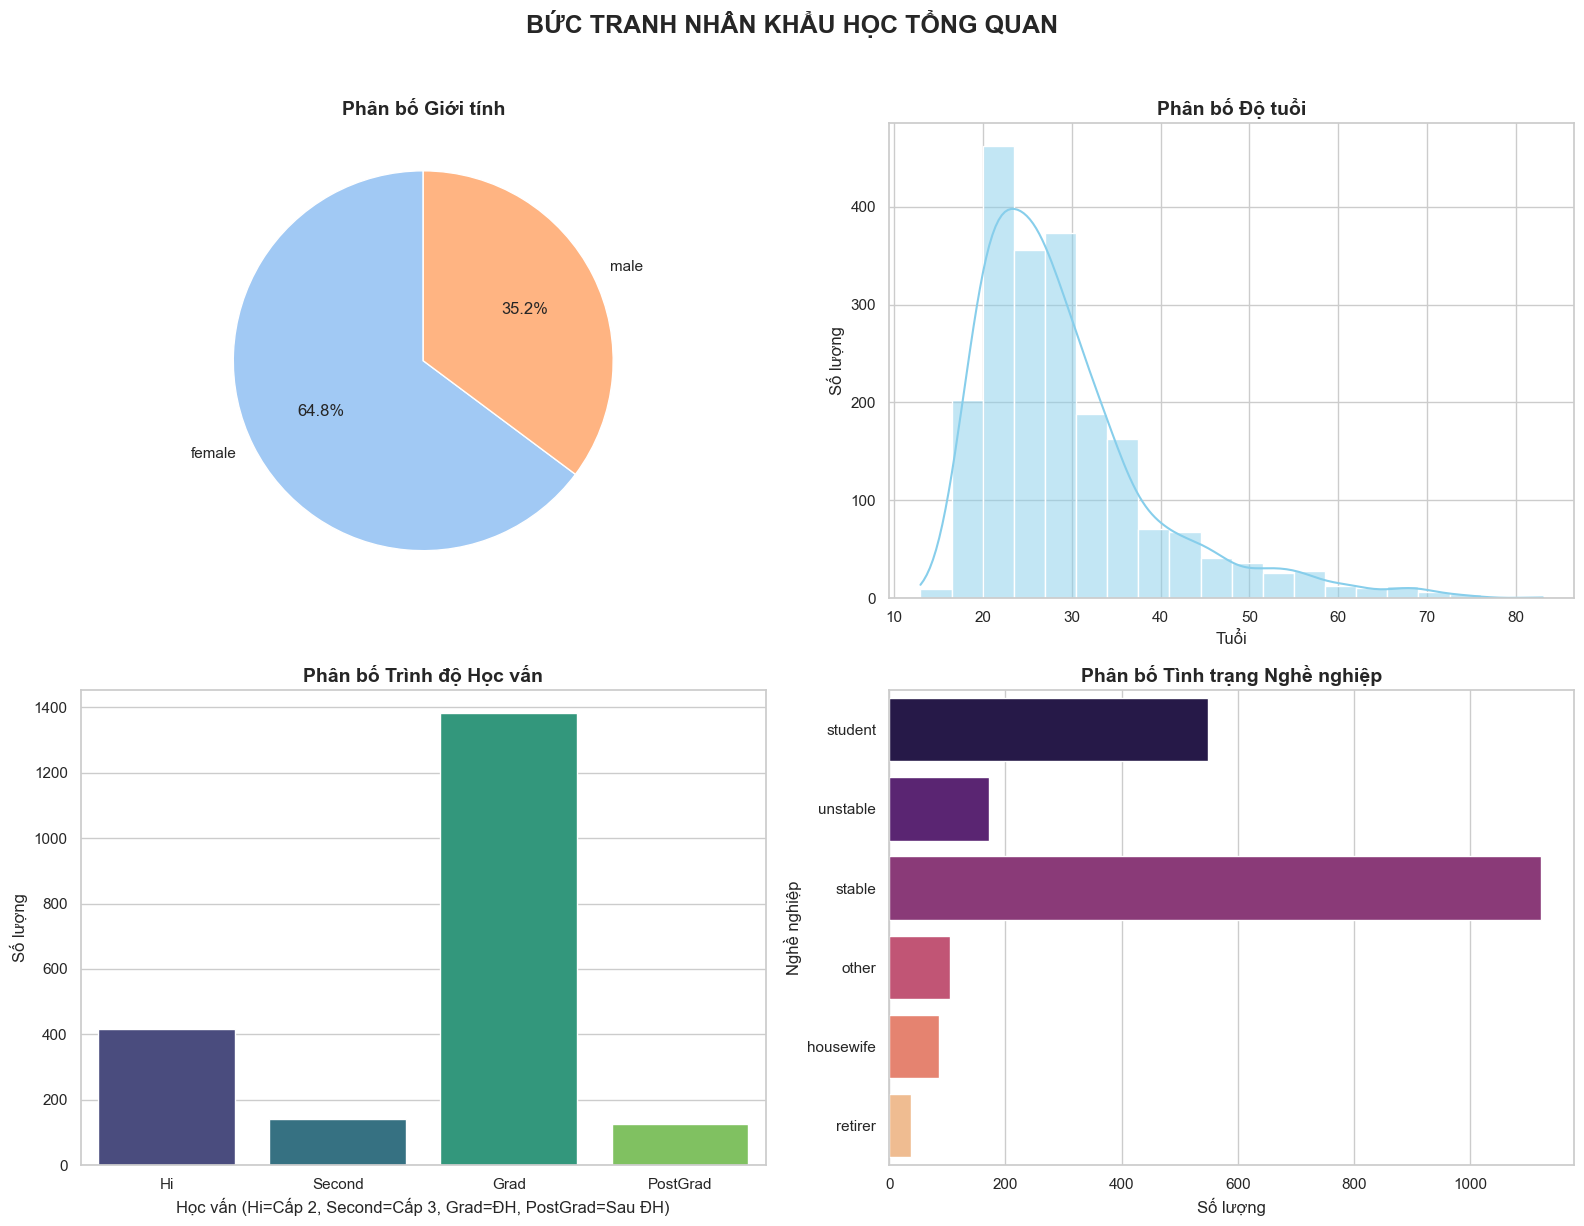

In [17]:
# Tạo khung vẽ (figure) với 4 ô con (2 hàng, 2 cột)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "BỨC TRANH NHÂN KHẨU HỌC TỔNG QUAN", fontsize=18, fontweight="bold", y=1.02
)

# 1. Phân bố Giới tính (Pie chart)
sex_counts = df["Sex"].value_counts()
axes[0, 0].pie(
    sex_counts,
    labels=sex_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel"),
)
axes[0, 0].set_title("Phân bố Giới tính", fontsize=14, fontweight="bold")

# 2. Phân bố Độ tuổi (Histogram)
sns.histplot(data=df, x="Age", bins=20, kde=True, ax=axes[0, 1], color="skyblue")
axes[0, 1].set_title("Phân bố Độ tuổi", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Tuổi")
axes[0, 1].set_ylabel("Số lượng")

# 3. Phân bố Học vấn (Countplot)
# Sắp xếp lại thứ tự học vấn từ thấp đến cao
edu_order = ["Hi", "Second", "Grad", "PostGrad"]
sns.countplot(data=df, x="Edu", order=edu_order, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Phân bố Trình độ Học vấn", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Học vấn (Hi=Cấp 2, Second=Cấp 3, Grad=ĐH, PostGrad=Sau ĐH)")
axes[1, 0].set_ylabel("Số lượng")

# 4. Phân bố Nghề nghiệp (Countplot dạng ngang)
sns.countplot(data=df, y="Jobstt", ax=axes[1, 1], palette="magma")
axes[1, 1].set_title("Phân bố Tình trạng Nghề nghiệp", fontsize=14, fontweight="bold")
axes[1, 1].set_xlabel("Số lượng")
axes[1, 1].set_ylabel("Nghề nghiệp")

# # in ra thông số kết quả của từng biểu đồ
# print("\nThông số phân bố Giới tính:")
# print(sex_counts)

# print("\nThông số phân bố Độ tuổi:")
# print(df["Age"].describe())

# print("\nThông số phân bố Học vấn:")
# print(df["Edu"].value_counts())

# print("\nThông số phân bố Nghề nghiệp:")
# print(df["Jobstt"].value_counts())


plt.tight_layout()
plt.show()


#### Nhận xét:

Từ 4 biểu đồ nhân khẩu học và số liệu thống kê, ta có thể phác họa rõ nét chân dung của nhóm đối tượng tham gia khảo sát với 3 đặc điểm cốt lõi:

- Sự áp đảo của Nữ giới và Giới trẻ: Tỷ lệ Nữ giới tham gia khảo sát cao gần gấp đôi Nam giới (1340 Nữ vs 728 Nam, chiếm ~64.8%). Về độ tuổi, tập dữ liệu cực kỳ trẻ hóa với độ tuổi trung bình chỉ khoảng 29.2 tuổi. Đáng chú ý, 75% số người được hỏi có độ tuổi dưới 33 (chủ yếu là Gen Z và Millennials). Insight: Nữ giới thường là người nắm giữ vai trò chăm sóc sức khỏe cho cả gia đình nên họ có xu hướng quan tâm và sẵn sàng trả lời khảo sát y tế hơn. Sự trẻ hóa của tập dữ liệu cũng mở ra một tín hiệu tốt cho việc ứng dụng các giải pháp công nghệ (HealthTech/App) ở các bước đề xuất sau này.

- Trình độ học vấn cao: Có một sự tập trung rất lớn ở nhóm có trình độ Đại học/Cao đẳng (Grad - 1383 người) và Sau Đại học (PostGrad - 127 người). Insight: Với nền tảng học vấn tốt, nhóm đối tượng này chắc chắn không thiếu "nhận thức" về tầm quan trọng của sức khỏe. Nếu họ lười đi khám, nguyên nhân gốc rễ chắc chắn đến từ các rào cản ngoại cảnh (thời gian, tiền bạc, trải nghiệm dịch vụ) chứ không phải do thiếu hiểu biết.

- Nghề nghiệp ổn định và Nhóm Sinh viên: Hơn 80% tập dữ liệu rơi vào nhóm có công việc ổn định (stable - 1123 người) và sinh viên (student - 548 người). Insight: Đây là nền tảng tuyệt vời để đặt ra giả thuyết cho Phần 2: Phải chăng người đi làm đang bị rào cản về "Thời gian" (quá bận rộn để đi khám), trong khi sinh viên lại bị rào cản về "Tài chính" (không có tiền đi khám định kỳ)?

### 1.2 Thể chất (BMI) theo Nhân khẩu học

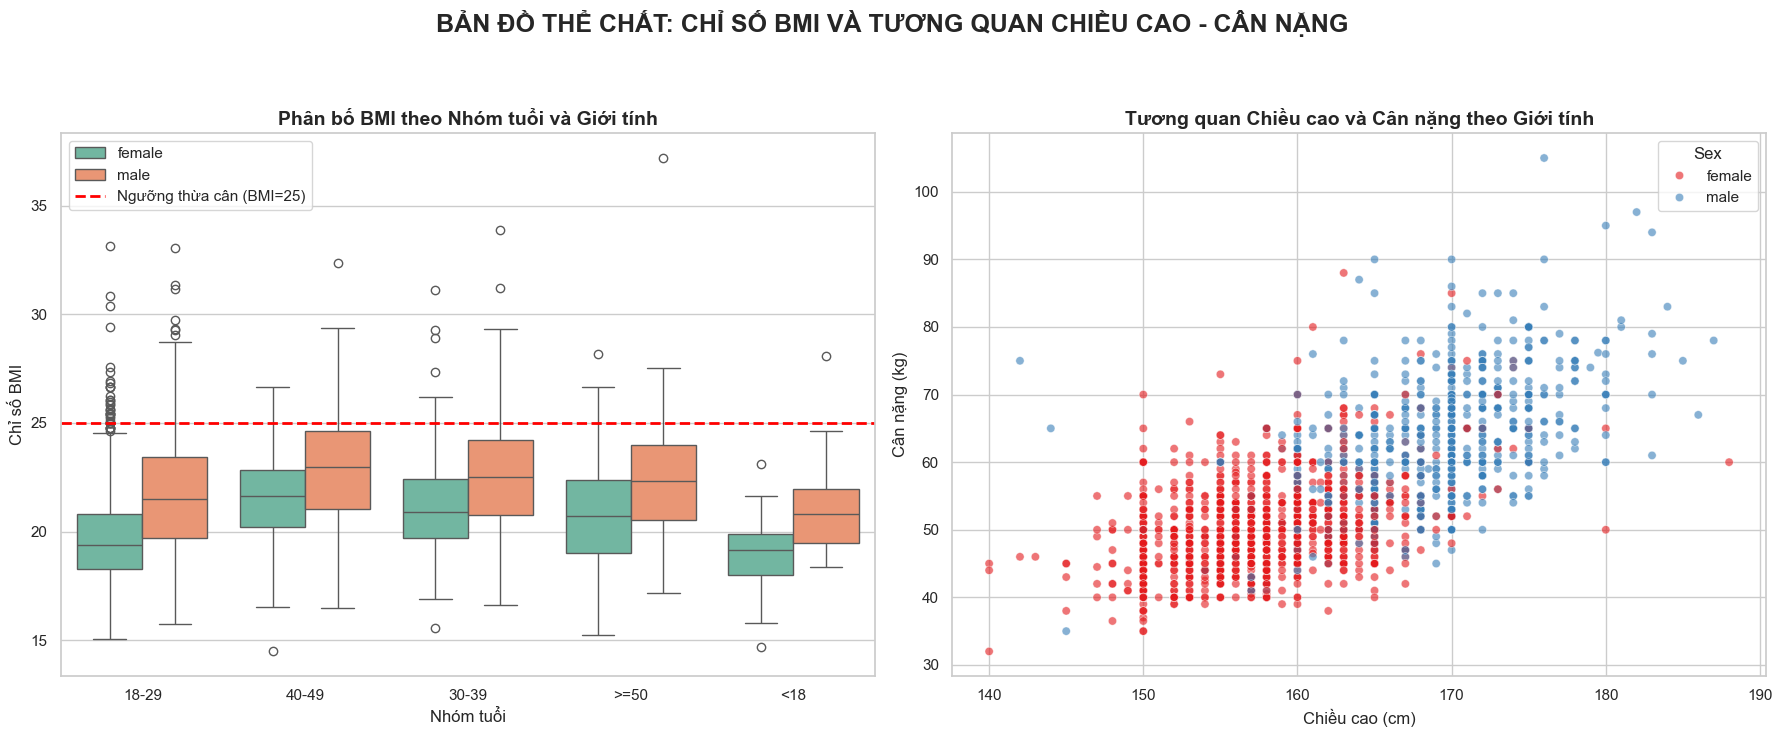

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    "BẢN ĐỒ THỂ CHẤT: CHỈ SỐ BMI VÀ TƯƠNG QUAN CHIỀU CAO - CÂN NẶNG",
    fontsize=18,
    fontweight="bold",
    y=1.05,
)

# 1. Boxplot BMI theo Nhóm tuổi và Giới tính
# Sắp xếp các nhóm tuổi (nếu Age_gr có định dạng string như '<20', '20-30',...)
# Nếu thứ tự hiển thị chưa chuẩn, ta có thể điều chỉnh sau
sns.boxplot(data=df, x="Age_gr", y="BMI", hue="Sex", ax=axes[0], palette="Set2")
axes[0].set_title(
    "Phân bố BMI theo Nhóm tuổi và Giới tính", fontsize=14, fontweight="bold"
)
axes[0].set_xlabel("Nhóm tuổi")
axes[0].set_ylabel("Chỉ số BMI")
# Vẽ đường tham chiếu BMI=25 (Ngưỡng bắt đầu thừa cân)
axes[0].axhline(
    25, color="red", linestyle="--", linewidth=2, label="Ngưỡng thừa cân (BMI=25)"
)
axes[0].legend()

# 2. Scatter plot Chiều cao vs Cân nặng
sns.scatterplot(
    data=df,
    x="height",
    y="weight",
    hue="Sex",
    alpha=0.6,
    ax=axes[1],
    palette="Set1",
)
axes[1].set_title(
    "Tương quan Chiều cao và Cân nặng theo Giới tính", fontsize=14, fontweight="bold"
)
axes[1].set_xlabel("Chiều cao (cm)")
axes[1].set_ylabel("Cân nặng (kg)")

# # in ra thông số kết quả của từng biểu đồ
# print("\nThông số BMI theo Nhóm tuổi và Giới tính:")
# for age_group in df["Age_gr"].unique():
#     for sex in df["Sex"].unique():
#         subset = df[(df["Age_gr"] == age_group) & (df["Sex"] == sex)]
#         if not subset.empty:
#             print(f"- {age_group} ({sex}): Trung bình = {subset['BMI'].mean():.2f}, Median = {subset['BMI'].median():.2f}")

# print("\nThông số Chiều cao và Cân nặng theo Giới tính:")
# for sex in df["Sex"].unique():
#     subset = df[df["Sex"] == sex]
#     if not subset.empty:
#         print(f"- {sex}: Chiều cao trung bình = {subset['height'].mean():.2f} cm, Cân nặng trung bình = {subset['weight'].mean():.2f} kg")


plt.tight_layout()
plt.show()


#### Nhận xét:
Phân tích tương quan giữa Chiều cao, Cân nặng và phân bố BMI theo độ tuổi/giới tính cho thấy bộ dữ liệu phản ánh rất chuẩn xác thể trạng thực tế của người Việt Nam:

- Thể trạng chung đạt chuẩn: Chiều cao và cân nặng trung bình của Nữ (157.68 cm - 50.12 kg) và Nam (168.72 cm - 63.08 kg) nằm ở mức tiêu chuẩn. Chỉ số BMI trung bình của tất cả các phân khúc tuổi đều xoay quanh mức 19 - 22.8 (nằm trong vùng an toàn, chưa vượt qua ngưỡng thừa cân BMI = 25).

- Xu hướng gia tăng BMI theo độ tuổi và giới tính: Dữ liệu chỉ ra một quy luật sinh học rõ ràng: Nam giới luôn có BMI cao hơn Nữ giới ở mọi lứa tuổi. Đặc biệt, nhóm Nam giới trung niên (40 - 49 tuổi) có mức BMI trung bình cao nhất (22.83). Dù trung bình chưa chạm mức béo phì, nhưng biểu đồ Boxplot chắc chắn sẽ xuất hiện nhiều điểm dị thường (outliers) nằm trên vạch đỏ (BMI > 25) ở nhóm tuổi này.

- Insight ứng dụng: Nhóm Nam giới trên 30 tuổi với xu hướng tăng cân (do đặc thù công việc, ít vận động, tiệc tùng) chính là tệp khách hàng có "nguy cơ bệnh lý ngầm" cao nhất nhưng lại thường có tâm lý chủ quan, ngại đi khám bệnh nhất. Mô hình AI cần phải đặc biệt chú ý đến cụm đặc trưng này.

# PHẦN 2: PHÂN TÍCH HÀNH VI & MỨC ĐỘ ƯU TIÊN SỨC KHỎE

### 2.1 Tần suất & Lý do khám bệnh :

***Mục tiêu: Trả lời câu hỏi "Nhóm nào lười đi khám nhất?" và xem họ đi khám vì tự nguyện hay bị ép buộc.***

<Figure size 1000x600 with 0 Axes>

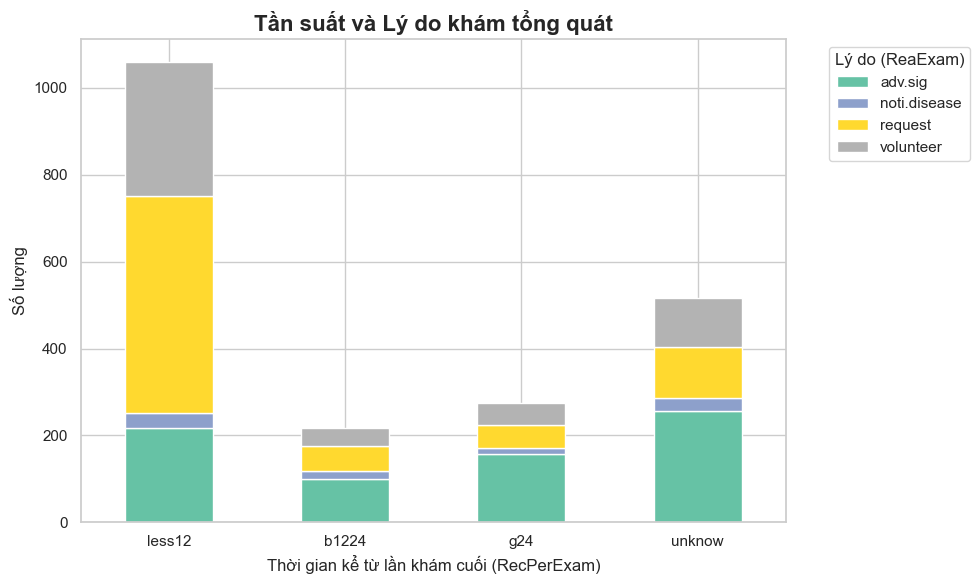

In [19]:
# --- 3. Phân tích Tần suất & Lý do khám bệnh (Stacked Bar Chart) ---
plt.figure(figsize=(10, 6))

# Sắp xếp lại thứ tự thời gian cho hợp lý từ gần nhất đến xa nhất/không nhớ
rec_order = ["less12", "b1224", "g24", "unknow"]

# Tạo bảng chéo (crosstab) giữa Tần suất và Lý do
cross_tab_3 = pd.crosstab(df["RecPerExam"], df["ReaExam"])
# Căn lại thứ tự hiển thị
if set(rec_order).issubset(cross_tab_3.index):
    cross_tab_3 = cross_tab_3.reindex(rec_order)

# Vẽ Stacked Bar Chart
cross_tab_3.plot(kind="bar", stacked=True, colormap="Set2", figsize=(10, 6))
plt.title("Tần suất và Lý do khám tổng quát", fontsize=16, fontweight="bold")
plt.xlabel("Thời gian kể từ lần khám cuối (RecPerExam)", fontsize=12)
plt.ylabel("Số lượng", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Lý do (ReaExam)", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# # --- IN RA THÔNG SỐ KẾT QUẢ ---
# print("Bảng thống kê Tần suất (RecPerExam) theo Lý do khám (ReaExam):")
# print(cross_tab_3)
# print("\nTổng số theo Lý do khám (ReaExam):")
# print(df["ReaExam"].value_counts())
# print("\nTổng số theo Tần suất khám (RecPerExam):")
# print(df["RecPerExam"].value_counts())


#### Nhận xét:
Phân tích chéo giữa Thời gian (RecPerExam) và Lý do khám (ReaExam) đã bóc trần một thực trạng đáng báo động về thói quen y tế dự phòng của người dân:

- Sự áp đảo của "Khám thụ động": Trong tổng số 2,068 người khảo sát, chỉ có khoảng 25% (514 người) đi khám vì lý do "tự nguyện" (volunteer). Phần lớn người dân chỉ tìm đến cơ sở y tế khi cơ thể đã xuất hiện triệu chứng bệnh rõ ràng (adv.sig - 730 người) hoặc do bị công ty/bảo hiểm bắt buộc (request - 726 người). Điều này cho thấy văn hóa "phòng bệnh hơn chữa bệnh" vẫn chưa thực sự bám rễ vào đời sống.

- Ảo ảnh của con số "Khám dưới 12 tháng": Thoạt nhìn, tập dữ liệu có vẻ rất tích cực khi có đến 1,059 người (chiếm hơn 50%) có lịch sử khám gần nhất là dưới 12 tháng (less12). Tuy nhiên, khi đối chiếu với lý do khám, ta thấy gần một nửa trong số đó (501 người) là đi khám do yêu cầu của công ty (request). Nhóm tự nguyện đi khám định kỳ hàng năm chỉ vỏn vẹn 307 người. Insight: Động lực duy trì sức khỏe cộng đồng hiện nay đang phụ thuộc rất lớn vào chính sách phúc lợi của các doanh nghiệp. Nếu không có các đợt khám sức khỏe định kỳ do công ty tổ chức, tỷ lệ người dân bỏ bê y tế tầm soát sẽ tăng vọt.

- Nhóm "Nguy cơ cao" (unknow): Đáng chú ý, có tới 516 người hoàn toàn không nhớ lần cuối mình đi khám là khi nào (unknow). Và khi nhóm này buộc phải đi khám, lý do chủ yếu là vì họ đã phát bệnh (adv.sig - 257 người). Đây chính là tập khách hàng trọng điểm mà mô hình AI cần nhận diện sớm để có biện pháp can thiệp.

### 2.2 Đối chiếu "Lời nói" và "Hành động" (Biến HthyPriority vs. Hành vi thực tế)

***Mục tiêu: Xem những người khẳng định "Sức khỏe là ưu tiên số 1" có thực sự đi khám định kỳ không.***

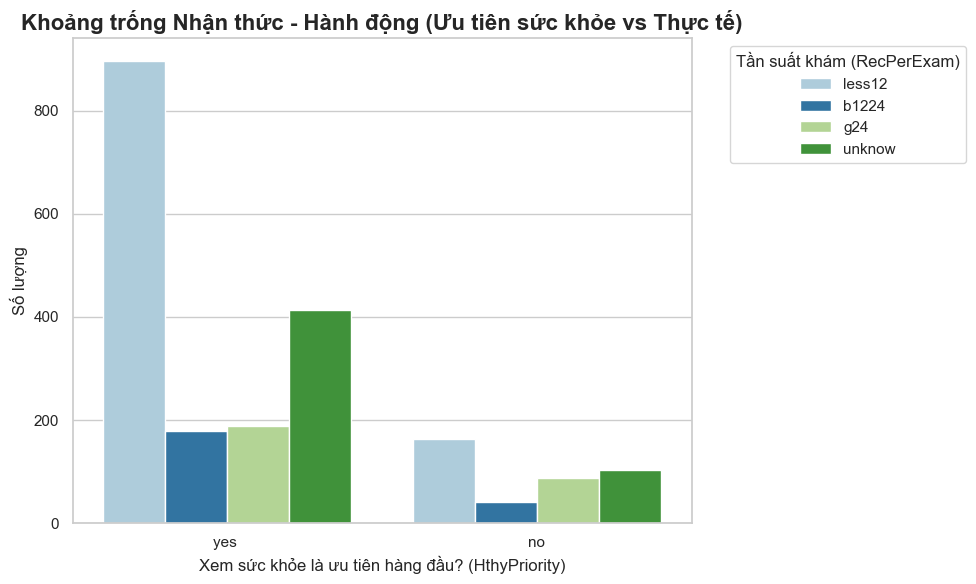

In [20]:
# --- 4. Đối chiếu "Lời nói" và "Hành động" (Grouped Bar Chart) ---
plt.figure(figsize=(10, 6))

rec_order = ["less12", "b1224", "g24", "unknow"]

# Xem xét mức độ ưu tiên sức khỏe (HthyPriority) với Tần suất khám (RecPerExam)
sns.countplot(
    data=df, x="HthyPriority", hue="RecPerExam", hue_order=rec_order, palette="Paired"
)
plt.title(
    "Khoảng trống Nhận thức - Hành động (Ưu tiên sức khỏe vs Thực tế)",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Xem sức khỏe là ưu tiên hàng đầu? (HthyPriority)", fontsize=12)
plt.ylabel("Số lượng", fontsize=12)
plt.legend(
    title="Tần suất khám (RecPerExam)", bbox_to_anchor=(1.05, 1), loc="upper left"
)
plt.tight_layout()
plt.show()

# # --- IN RA THÔNG SỐ KẾT QUẢ ---
# print("Bảng thống kê Ưu tiên sức khỏe (HthyPriority) vs Hành vi thực tế (RecPerExam):")
# cross_tab_4 = pd.crosstab(df["HthyPriority"], df["RecPerExam"])
# if set(rec_order).issubset(cross_tab_4.columns):
#     cross_tab_4 = cross_tab_4[rec_order]  # Sắp xếp cột
# print(cross_tab_4)
# print("\nTổng số theo Mức độ ưu tiên sức khỏe (HthyPriority):")
# print(df["HthyPriority"].value_counts())


#### Nhận xét:
Việc đối chiếu giữa mức độ ưu tiên sức khỏe (HthyPriority) và hành vi thực tế đã chỉ ra một "khoảng trống nhận thức" vô cùng sâu sắc:

- Nhận thức rất cao: Có đến 1,675 người (chiếm 81% tập dữ liệu) tự tin khẳng định rằng "Sức khỏe là ưu tiên hàng đầu" của họ (HthyPriority = yes).

- Hành động tỷ lệ nghịch: Tuy nhiên, trong số 1,675 người luôn đề cao sức khỏe đó, có một nghịch lý lớn: 188 người đã bỏ bê không khám bệnh suốt hơn 2 năm qua (g24), và tệ hơn, 413 người thậm chí không nhớ nổi lần cuối mình đi khám là khi nào (unknow). Tổng cộng, có hơn 600 người (chiếm gần 36% nhóm "có ý thức") đang thất bại trong việc chuyển hóa nhận thức thành hành động thực tế.

- Dẫn nhập: Việc người dân ý thức được tầm quan trọng của sức khỏe nhưng vẫn chần chừ, trì hoãn việc tầm soát y tế chứng tỏ đang tồn tại những "rào cản vô hình" cực kỳ lớn cản bước họ. Đó có thể là áp lực tài chính, quỹ thời gian eo hẹp, hoặc một chướng ngại tâm lý (sợ phát hiện ra bệnh). Phân tích chi tiết các rào cản này sẽ được làm rõ ở Phần tiếp theo.

$\implies$ <em> sự thật rằng: Hầu hết người ta đi khám đều đặn là do công ty ép, và rất nhiều người miệng nói quan tâm sức khỏe nhưng thực tế lại không hề đi khám. <em>

# PHẦN 3: PHÂN TÍCH LỐI SỐNG VÀ THÓI QUEN VẬN ĐỘNG (LIFESTYLE & EXERCISE)

### 3.1 Nhận thức với Thực hành trong việc tập thể dục

***Mục tiêu: So sánh đánh giá mức độ tập thể dục thực tế (EvalExer) và Hành vi khám định kỳ (RecPerExam).***

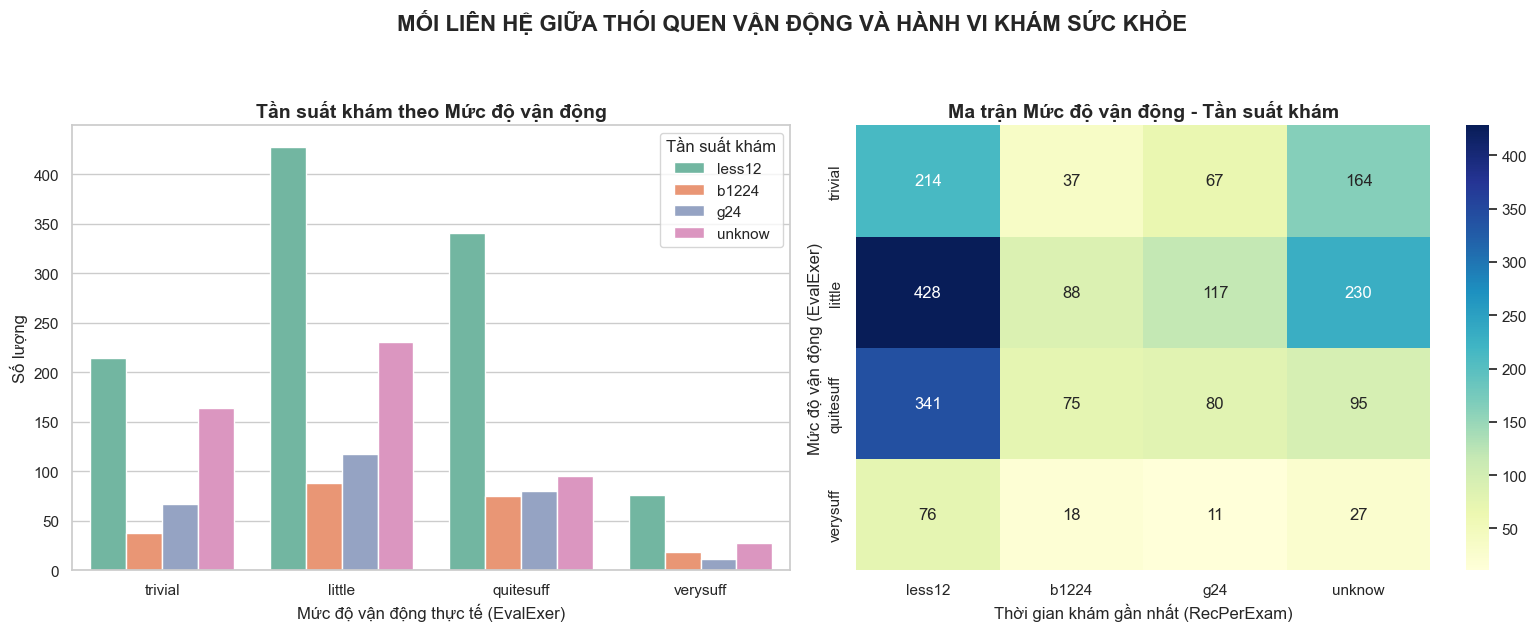

Bảng thống kê Mức độ vận động (EvalExer) vs Hành vi thực tế (RecPerExam):
RecPerExam  less12  b1224  g24  unknow
EvalExer                              
trivial        214     37   67     164
little         428     88  117     230
quitesuff      341     75   80      95
verysuff        76     18   11      27

Tổng số theo Mức độ vận động (EvalExer):
EvalExer
trivial      482
little       863
quitesuff    591
verysuff     132
Name: count, dtype: int64

Mẫu các giá trị trong SuitExer (Dạng Text):
SuitExer
unknown    729
420        346
210        310
300         90
180         46
Name: count, dtype: int64


In [21]:
# --- 5. Đánh giá Mức độ tập luyện (EvalExer) vs Tần suất khám (RecPerExam) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "MỐI LIÊN HỆ GIỮA THÓI QUEN VẬN ĐỘNG VÀ HÀNH VI KHÁM SỨC KHỎE",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)

# Sắp xếp thứ tự cho logic: từ Lười vận động -> Chăm vận động
eval_order = ["trivial", "little", "quitesuff", "verysuff"]
rec_order = ["less12", "b1224", "g24", "unknow"]

# Biểu đồ 1: Grouped Bar Chart so sánh
sns.countplot(
    data=df,
    x="EvalExer",
    hue="RecPerExam",
    order=eval_order,
    hue_order=rec_order,
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Tần suất khám theo Mức độ vận động", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Mức độ vận động thực tế (EvalExer)")
axes[0].set_ylabel("Số lượng")
axes[0].legend(title="Tần suất khám")

# Biểu đồ 2: Heatmap (Bản đồ nhiệt) để thấy sự tập trung dữ liệu
cross_tab_5 = pd.crosstab(df["EvalExer"], df["RecPerExam"])
# Reindex để sắp xếp lại trục cho đúng thứ tự
if set(eval_order).issubset(cross_tab_5.index) and set(rec_order).issubset(
    cross_tab_5.columns
):
    cross_tab_5 = cross_tab_5.reindex(index=eval_order, columns=rec_order)

sns.heatmap(cross_tab_5, annot=True, fmt="d", cmap="YlGnBu", ax=axes[1], cbar=True)
axes[1].set_title(
    "Ma trận Mức độ vận động - Tần suất khám", fontsize=14, fontweight="bold"
)
axes[1].set_xlabel("Thời gian khám gần nhất (RecPerExam)")
axes[1].set_ylabel("Mức độ vận động (EvalExer)")

plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ĐỂ NHẬN XÉT ---
print("Bảng thống kê Mức độ vận động (EvalExer) vs Hành vi thực tế (RecPerExam):")
print(cross_tab_5)

print("\nTổng số theo Mức độ vận động (EvalExer):")
print(df["EvalExer"].value_counts().reindex(eval_order))

# Thống kê riêng biến Nhận thức tập luyện (SuitExer) nếu là dạng số
if pd.api.types.is_numeric_dtype(df["SuitExer"]):
    print("\nThống kê thời gian tập luyện lý tưởng (SuitExer - phút/giờ):")
    print(df["SuitExer"].describe())
else:
    print("\nMẫu các giá trị trong SuitExer (Dạng Text):")
    print(df["SuitExer"].value_counts().head())


#### Nhận xét:
3.1. Thực trạng: Căn bệnh "lười vận động" và sự thiếu hụt kiến thức thể chất  
Dữ liệu phân bổ của biến EvalExer phản ánh một thực trạng đáng lo ngại về lối sống tĩnh tại của nhóm đối tượng khảo sát:

- Tỷ lệ lười vận động chiếm áp đảo: Có đến 1,345 người (chiếm khoảng 65% tổng số 2,068 mẫu) thừa nhận rằng họ hoàn toàn không tập thể dục (trivial - 482 người) hoặc tập rất ít (little - 863 người). Chỉ có khoảng 35% duy trì được thói quen vận động từ mức đủ (quitesuff) đến rất thường xuyên (verysuff).

- Khoảng trống kiến thức (Health Literacy): Khi được hỏi về thời gian tập luyện lý tưởng (SuitExer), có đến 729 người (chiếm hơn 35%) trả lời là unknown (không biết). Những người còn lại có đưa ra các con số (như 420 phút/tuần, 210 phút/tuần) nhưng sự áp đảo của nhóm unknown cho thấy một lỗ hổng lớn trong truyền thông giáo dục sức khỏe: Người dân không chỉ lười tập, mà họ còn không biết tiêu chuẩn tập luyện cơ bản để duy trì một cơ thể khỏe mạnh là bao nhiêu.

3.2. Tương quan thuận: Lối sống tĩnh tại và Sự thờ ơ với y tế dự phòng  
- Phân tích chéo (Crosstab) giữa mức độ vận động và hành vi khám sức khỏe đã chứng minh xuất sắc giả thuyết ban đầu của chúng ta: Những người bỏ bê cơ thể hàng ngày cũng chính là những người bỏ bê việc tầm soát bệnh tật.

- Nhóm lười vận động (Trivial / Little): Trong 482 người hoàn toàn không tập thể dục (trivial), có đến 231 người (gần 48%) rơi vào nhóm lười đi khám (chưa khám trên 24 tháng hoặc không nhớ lần cuối đi khám unknow). Tương tự ở nhóm tập rất ít (little), tỷ lệ lười khám cũng ở mức rất cao (40%).

- Nhóm năng động (Quitesuff / Verysuff): Sự cải thiện xuất hiện rõ rệt ở nhóm có ý thức tập luyện. Trong nhóm tập luyện đầy đủ (quitesuff), tỷ lệ lười đi khám giảm mạnh xuống chỉ còn khoảng 29.6% (175/591 người). Tỷ lệ này tiếp tục duy trì ở mức thấp 28.7% đối với nhóm tập rất siêng năng (verysuff).

$\implies$ Hành vi chăm sóc sức khỏe là một chuỗi thống nhất. Dữ liệu đã khẳng định một quy luật hành vi: Thói quen vận động (EvalExer) là một "biến tiên lượng" (predictor) cực kỳ mạnh mẽ để dự đoán hành vi khám bệnh.

$\implies$ Một cá nhân thiếu kỷ luật trong việc duy trì thói quen thể chất hàng ngày (mức trivial hoặc little) có xác suất rơi vào nhóm "nguy cơ cao" (bỏ bê y tế dự phòng) cao gần gấp đôi so với những người có lối sống năng động

# PHẦN 4: PHÂN TÍCH RÀO CẢN TÂM LÝ & KINH TẾ

### PHẦN 4.1 - BỘ BA RÀO CẢN

***Mục tiêu: Vẽ biểu đồ mạng nhện so sánh nỗi sợ tốn tiền (Wstmon), tốn thời gian (Wsttime) và sợ lòi ra bệnh (DiscDisease) giữa các nhóm nghề nghiệp.***

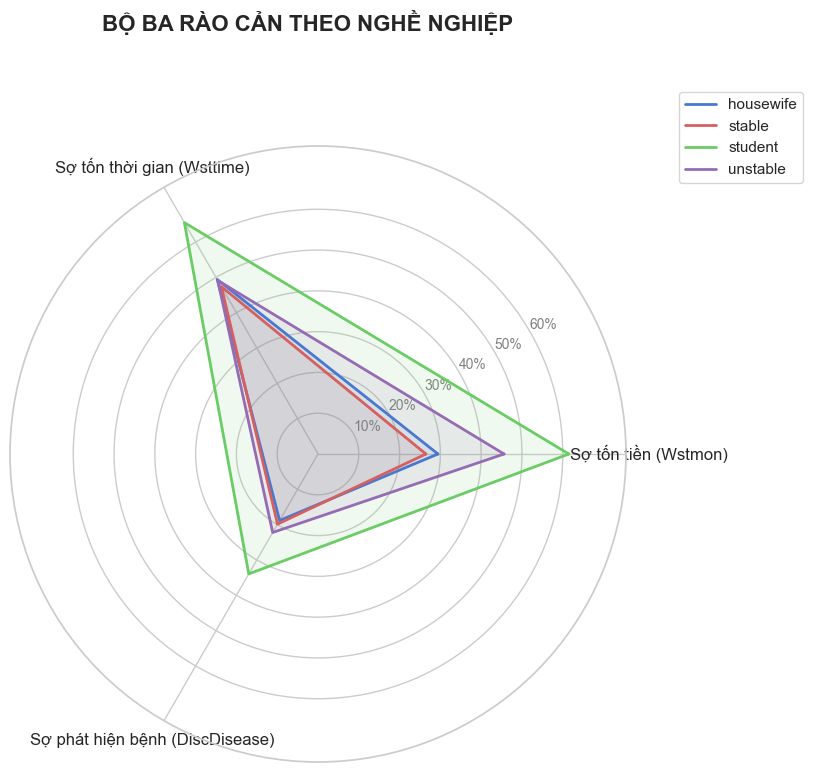

4.1 Tỷ lệ % trả lời CÓ gặp rào cản theo từng nhóm nghề nghiệp:
      Jobstt     Wstmon    Wsttime  DiscDisease
0  housewife  29.411765  49.411765    18.823529
1     stable  26.447017  47.373108    19.857524
2    student  61.496350  65.510949    33.941606
3   unstable  45.614035  49.122807    22.222222

Kiểm tra giá trị thô của biến Wstmon:
Wstmon
no     1298
yes     770
Name: count, dtype: int64

Kiểm tra giá trị thô của biến DiscDisease:
DiscDisease
no     1585
yes     483
Name: count, dtype: int64


In [22]:
from math import pi
import matplotlib.pyplot as plt

# --- 6. Bộ ba rào cản: Tiền bạc - Thời gian - Nỗi sợ ---
barriers = ["Wstmon", "Wsttime", "DiscDisease"]

# Lọc ra 4 nhóm nghề nghiệp chính
target_jobs = ["stable", "student", "unstable", "housewife"]
df_radar = df[df["Jobstt"].isin(target_jobs)]

# SỬA LỖI TẠI ĐÂY: Dùng apply cho từng cột (Series) bên trong DataFrame
radar_data = (
    df_radar.groupby("Jobstt")[barriers]
    .apply(
        lambda g: g.astype(str).apply(lambda col: col.str.lower() == "yes").mean() * 100
    )
    .reset_index()
)

# Chuẩn bị dữ liệu vẽ Radar Chart
categories = barriers
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Nối điểm cuối với điểm đầu để khép kín vòng

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle("BỘ BA RÀO CẢN THEO NGHỀ NGHIỆP", fontsize=16, fontweight="bold", y=1.05)

colors = ["b", "r", "g", "m"]
for i, row in radar_data.iterrows():
    values = row[categories].tolist()
    values += values[:1]  # Khép kín vòng
    ax.plot(
        angles,
        values,
        linewidth=2,
        linestyle="solid",
        label=row["Jobstt"],
        color=colors[i],
    )
    ax.fill(angles, values, color=colors[i], alpha=0.1)

plt.xticks(
    angles[:-1],
    [
        "Sợ tốn tiền (Wstmon)",
        "Sợ tốn thời gian (Wsttime)",
        "Sợ phát hiện bệnh (DiscDisease)",
    ],
    size=12,
)
ax.set_rlabel_position(30)
plt.yticks(
    [10, 20, 30, 40, 50, 60],
    ["10%", "20%", "30%", "40%", "50%", "60%"],
    color="grey",
    size=10,
)
plt.ylim(
    0, max(radar_data[barriers].max()) + 10
)  # Tự động giãn trục y theo số liệu thực tế
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()

# --- IN RA THÔNG SỐ ---
print("4.1 Tỷ lệ % trả lời CÓ gặp rào cản theo từng nhóm nghề nghiệp:")
print(radar_data)
print("\nKiểm tra giá trị thô của biến Wstmon:")
print(df["Wstmon"].value_counts())
print("\nKiểm tra giá trị thô của biến DiscDisease:")
print(df["DiscDisease"].value_counts())


#### Nhận xét:
Tiền bạc - Thời gian - Tâm lý theo Nhóm nghề nghiệp và dữ liệu thống kê đã làm sáng tỏ những "nỗi đau" (pain points) thực sự ngăn cản người dân đến với các cơ sở y tế dự phòng. Kết quả cho thấy sự phân hóa cực kỳ rõ nét dựa trên tính chất công việc:

- **Thời gian (Wsttime)** - Rào cản mang tính phổ quát: Đáng chú ý, "Sợ tốn thời gian" là rào cản lớn nhất đối với gần như mọi nhóm đối tượng. Có đến 47% người có công việc ổn định (stable), 49% lao động tự do (unstable) và nội trợ (housewife) coi việc đi khám là mất thời gian. Quỹ thời gian eo hẹp, kết hợp với quy trình chờ đợi khám chữa bệnh rườm rà tại các cơ sở y tế (đã được chứng minh ở biến Respon thấp trong Phần 1), chính là "điểm nghẽn" lớn nhất của hệ thống y tế hiện nay.

- **Tài chính (Wstmon)** - Gánh nặng của nhóm bấp bênh: Đúng như giả thuyết ban đầu, yếu tố tiền bạc có sự phân hóa mạnh mẽ theo thu nhập. Tỷ lệ lo ngại chi phí khám bệnh ở nhóm người đi làm ổn định (stable) và nội trợ (housewife) chỉ ở mức thấp (26 - 29%). Tuy nhiên, con số này tăng vọt lên 45.6% ở nhóm lao động tự do (unstable). Điều này chứng tỏ chi phí y tế vẫn là một gánh nặng đáng kể đối với nhóm thu nhập không cố định.

- **Nhóm Sinh viên (Student)** - Sự khủng hoảng kép: Bất ngờ lớn nhất từ dữ liệu là nhóm Sinh viên. Trái với suy nghĩ người trẻ thường năng động và ít lo nghĩ, dữ liệu cho thấy sinh viên là nhóm chịu áp lực nặng nề nhất từ cả 3 rào cản:

	- Sợ tốn tiền cao kỉ lục: 61.5%

	- Sợ tốn thời gian cao kỉ lục: 65.5%

	- Thậm chí, hội chứng "Sợ lòi ra bệnh" (DiscDisease) cũng đạt đỉnh ở nhóm này (33.9%, so với mức trung bình chỉ ~20% ở các nhóm khác).

	- Insight: Người trẻ sinh viên hiện nay đang đối mặt với áp lực học tập/làm thêm rất lớn, ngân sách eo hẹp và có xu hướng tâm lý né tránh bệnh tật (thà không biết để khỏi lo nghĩ). Đây là nhóm "tổn thương ngầm" cực kỳ cần các chiến dịch giáo dục y tế học đường can thiệp.

$\Rightarrow$ ***Để tăng tỷ lệ khám chủ động, các cơ sở y tế không thể áp dụng một công thức chung. Đối với người đi làm, giải pháp phải là "Tối ưu hóa thời gian" (ví dụ: ứng dụng đặt lịch online, khám ngoài giờ). Đối với sinh viên và lao động tự do, giải pháp phải là "Tối ưu hóa chi phí" (gói khám sinh viên, trợ giá).***

### PHẦN 4.2 - QUYỀN NĂNG CỦA BẢO HIỂM Y TẾ

***Mục tiêu: Xem nhóm có BHYT (HealthIns) thì tỷ lệ khám chủ động (less12, b1224) có cao hơn hẳn nhóm không có BHYT không.***

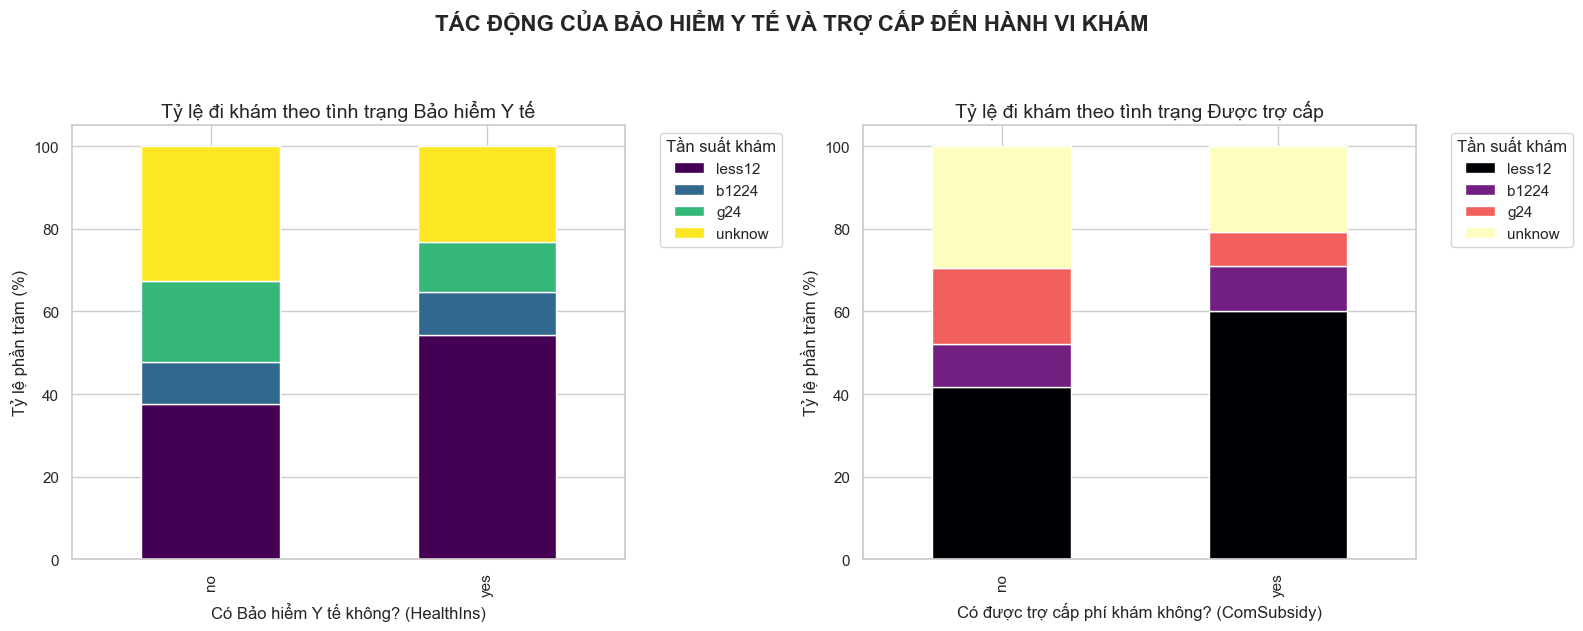

Bảng Tỷ lệ % Tần suất khám theo Bảo hiểm y tế (HealthIns):
RecPerExam  less12  b1224    g24  unknow
HealthIns                               
no           37.50  10.33  19.57   32.61
yes          54.18  10.59  11.94   23.29

Bảng Tỷ lệ % Tần suất khám theo Trợ cấp (ComSubsidy):
RecPerExam  less12  b1224    g24  unknow
ComSubsidy                              
no           41.81  10.33  18.47   29.39
yes          60.13  10.74   8.39   20.74

Số lượng người CÓ/KHÔNG có Bảo hiểm Y tế thực tế:
HealthIns
yes    1700
no      368
Name: count, dtype: int64


In [23]:
# --- 7. Quyền năng của Bảo hiểm y tế (100% Stacked Bar chart) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "TÁC ĐỘNG CỦA BẢO HIỂM Y TẾ VÀ TRỢ CẤP ĐẾN HÀNH VI KHÁM",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)

rec_order = ["less12", "b1224", "g24", "unknow"]

# Biểu đồ 1: Bảo hiểm y tế (HealthIns)
# Tính % chéo: normalize='index' giúp tính tổng mỗi hàng (Yes/No) = 100%
cross_ins = (
    pd.crosstab(df["HealthIns"], df["RecPerExam"], normalize="index")[rec_order] * 100
)
cross_ins.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_title("Tỷ lệ đi khám theo tình trạng Bảo hiểm Y tế", fontsize=14)
axes[0].set_ylabel("Tỷ lệ phần trăm (%)")
axes[0].set_xlabel("Có Bảo hiểm Y tế không? (HealthIns)")
axes[0].legend(title="Tần suất khám", bbox_to_anchor=(1.05, 1), loc="upper left")

# Biểu đồ 2: Trợ cấp cộng đồng/công ty (ComSubsidy)
cross_sub = (
    pd.crosstab(df["ComSubsidy"], df["RecPerExam"], normalize="index")[rec_order] * 100
)
cross_sub.plot(kind="bar", stacked=True, ax=axes[1], colormap="magma")
axes[1].set_title("Tỷ lệ đi khám theo tình trạng Được trợ cấp", fontsize=14)
axes[1].set_ylabel("Tỷ lệ phần trăm (%)")
axes[1].set_xlabel("Có được trợ cấp phí khám không? (ComSubsidy)")
axes[1].legend(title="Tần suất khám", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ ---
print("Bảng Tỷ lệ % Tần suất khám theo Bảo hiểm y tế (HealthIns):")
print(cross_ins.round(2))
print("\nBảng Tỷ lệ % Tần suất khám theo Trợ cấp (ComSubsidy):")
print(cross_sub.round(2))
print("\nSố lượng người CÓ/KHÔNG có Bảo hiểm Y tế thực tế:")
print(df["HealthIns"].value_counts())


#### Nhận xét:
Số liệu thống kê đã đo lường chính xác tác động của các đòn bẩy tài chính đối với quyết định đi khám sức khỏe của người dân:

- Tài chính là đòn bẩy cực mạnh (Financial Leverage): Dữ liệu khẳng định rõ ràng rằng khi gánh nặng tài chính được trút bỏ, tỷ lệ người dân chủ động đi khám tăng vọt.

	- Đối với Bảo hiểm Y tế (HealthIns): Nhóm có BHYT có tỷ lệ đi khám định kỳ dưới 12 tháng (less12) đạt 54.18%, cao gấp rưỡi so với nhóm không có BHYT (chỉ đạt 37.50%). Đồng thời, nhóm không có BHYT có tỷ lệ "không nhớ lần cuối đi khám" (unknow) lên tới 32.61%.

	- Đối với Trợ cấp (ComSubsidy): Quyền năng của trợ cấp (từ công ty hoặc cộng đồng) còn mạnh mẽ hơn cả BHYT. Những người được trợ cấp có tỷ lệ khám thường xuyên (less12) lên đến 60.13%, trong khi tỷ lệ bỏ bê y tế (g24 và unknow) giảm xuống mức thấp nhất (chỉ còn khoảng 29.13%).

- Nghịch lý "Có thẻ nhưng không dùng" (Tiền không phải là tất cả): Dù độ phủ của Bảo hiểm Y tế trong tập dữ liệu là cực kỳ cao (1,700 người có BHYT trên tổng số 2,068 người), nhưng có một "khoảng trống" rất đáng báo động. Trong số 1,700 người được bảo vệ bởi BHYT này, vẫn có tới hơn 35% lười đi khám (gồm 11.94% đã hơn 2 năm không khám và 23.29% không nhớ nổi lần cuối đi khám).

	- Insight cốt lõi: Nếu tiền bạc là rào cản duy nhất, thì những người có BHYT đã phải đi khám 100%. Việc hàng trăm người có BHYT nhưng vẫn từ chối đến bệnh viện chứng tỏ đang tồn tại những "nút thắt" nghiêm trọng khác. Đó có thể là rào cản về thủ tục hành chính rườm rà, thời gian chờ đợi lấy số lâu (như đã phân tích ở biến Wsttime phần 4.1), hoặc chất lượng phục vụ của tuyến BHYT chưa đáp ứng được kỳ vọng, khiến người dân "thà chịu bệnh còn hơn đi hành xác".

$\Rightarrow$ ***Các chính sách hỗ trợ tài chính (BHYT, Trợ cấp) là điều kiện cần, nhưng chưa đủ để xây dựng văn hóa y tế dự phòng chủ động. Muốn kéo người dân đến phòng khám, việc phát thẻ BHYT phải đi kèm với việc cải tổ trải nghiệm dịch vụ và rút ngắn thời gian chờ đợi.***

### PHẦN 4.3 - BÀI TEST TÂM LÝ

***Mục tiêu: Nếu được cho tiền để đi khám (UseMon), họ sẽ đi ngay (allsoon), đi một phần (partly), hay lấy tiền làm việc khác (later).***

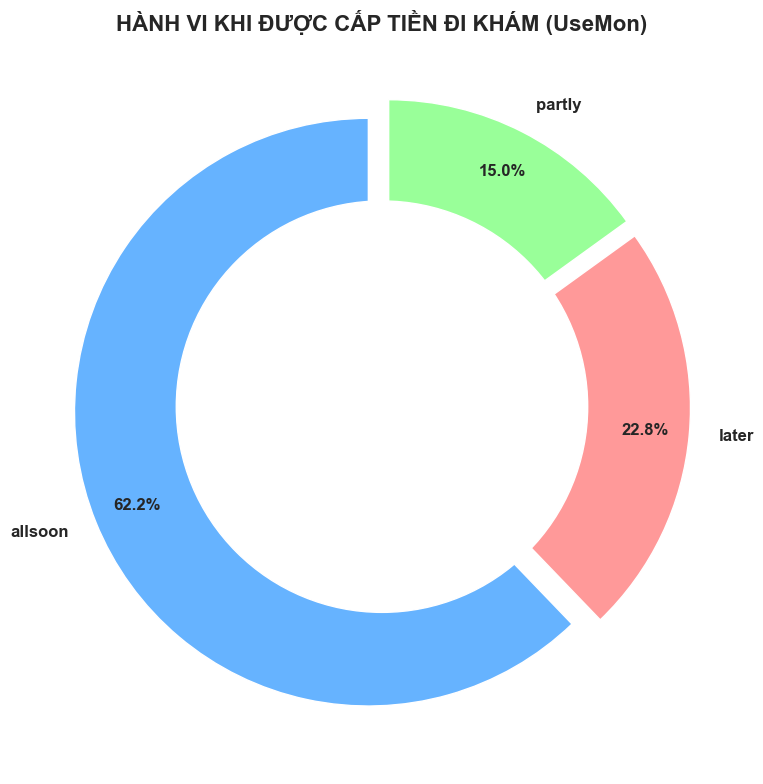

Phân bổ các quyết định khi được cho tiền khám (UseMon):
UseMon
allsoon    1286
later       471
partly      311
Name: count, dtype: int64


In [24]:
# --- 8. Bài test Tâm lý học Hành vi (Donut chart) ---
plt.figure(figsize=(8, 8))

# Lấy dữ liệu và loại bỏ các giá trị null nếu có
usemon_counts = df["UseMon"].value_counts()

# Màu sắc
colors = ["#66b3ff", "#ff9999", "#99ff99"]
explode = (0.05, 0.05, 0.05)  # Tách các miếng ra một chút

# Vẽ Pie chart
plt.pie(
    usemon_counts,
    labels=usemon_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85,
    colors=colors,
    explode=explode,
    textprops={"fontsize": 12, "weight": "bold"},
)

# Vẽ hình tròn trắng ở giữa để tạo thành Donut (Bánh donut)
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("HÀNH VI KHI ĐƯỢC CẤP TIỀN ĐI KHÁM (UseMon)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ ---
print("Phân bổ các quyết định khi được cho tiền khám (UseMon):")
print(usemon_counts)


#### Nhận xét:
Kết quả từ câu hỏi giả định "Nếu được cấp tiền mặt để đi khám, bạn sẽ làm gì?" (UseMon) đã phân tách cực kỳ chính xác hai nhóm tâm lý cốt lõi của người dân:

- **Nhóm "Thực sự thiếu tiền" (Động lực tài chính đóng vai trò quyết định)**: Đa số người tham gia khảo sát **(1,286 người, chiếm khoảng 62.2%)** chọn phương án allsoon – sử dụng toàn bộ số tiền để đi khám ngay lập tức. Điều này khẳng định rằng đối với gần 2/3 dân số, rào cản lớn nhất và trực tiếp nhất vẫn là gánh nặng chi phí. Chỉ cần có sự hỗ trợ tài chính trực tiếp, hành vi y tế của họ sẽ được kích hoạt ngay lập tức.

- **Nhóm "Thờ ơ và Trì hoãn" (Tiền không giải quyết được vấn đề)**: Đáng báo động là nhóm còn lại, chiếm gần **38% (bao gồm 471 người chọn later và 311 người chọn partly)**. Đặc biệt là nhóm later (22.8%) – những người cầm tiền nhưng quyết định dời việc khám lại sau để ưu tiên cho các nhu cầu cá nhân khác. Đối với nhóm này, sức khỏe hoàn toàn không phải là ưu tiên cấp bách. Sự trì hoãn của họ xuất phát từ rào cản tâm lý sâu sắc (sợ phát hiện bệnh, lười biếng, sợ tốn thời gian chờ đợi) chứ không còn nằm ở bài toán kinh tế.

***TỔNG KẾT PHẦN 4: CHÂN DUNG RÀO CẢN VÀ ĐỊNH HƯỚNG GIẢI PHÁP***  
Việc đào sâu vào 3 khía cạnh (Tâm lý nghề nghiệp, Quyền năng Bảo hiểm và Bài test hành vi) đã cung cấp một góc nhìn đa chiều về những rào cản ngăn cách người dân với y tế dự phòng. Chúng ta có thể rút ra 3 kết luận mang tính định hướng cho việc xây dựng mô hình AI và giải pháp kinh doanh (Business Insights):

- Không có một rào cản độc tôn: Người dân không đi khám vì một ma trận các nguyên nhân đan xen. Người đi làm vướng bận thời gian, lao động tự do lo âu về tài chính, trong khi nhóm sinh viên lại chịu "khủng hoảng kép" từ cả tiền bạc, thời gian lẫn nỗi sợ hãi bệnh tật.

- Giới hạn của các công cụ hỗ trợ tài chính: Các chính sách như Bảo hiểm Y tế hay Trợ cấp công ty là những đòn bẩy tuyệt vời (giúp tỷ lệ khám tăng vọt lên 54-60%), nhưng chúng đã chạm đến "ngưỡng giới hạn". Vẫn có hơn 1/3 số người có BHYT, hoặc được cho tiền mặt, nhưng kiên quyết không đi khám ngay.

- Định hướng Giải pháp ứng dụng: Để phá vỡ khối trì hoãn của 1/3 dân số còn lại, hệ thống y tế cần các "cú hích" phi tài chính. Giải pháp không chỉ là giảm giá, mà phải là tối ưu hóa trải nghiệm: rút ngắn thời gian chờ (giải quyết rào cản Wsttime), cung cấp gói khám tận nơi, hoặc ứng dụng công nghệ (Telemedicine/Health App) để nhắc nhở và xoa dịu tâm lý e ngại của bệnh nhân. Đây chính là tiền đề quan trọng nhất để xây dựng các giải pháp ứng dụng ở phần cuối của đồ án.

# PHẦN 5: ĐÁNH GIÁ TRẢI NGHIỆM DỊCH VỤ Y TẾ

***Đây là phần phân tích để các cơ sở y tế nhìn nhận lại chính mình. Bệnh nhân mất niềm tin (Lessbelqual = Yes) là do cơ sở vật chất tồi tàn (Tangibles), hay do thái độ vô cảm của y bác sĩ (Empathy), hay vì họ phải chờ đợi quá lâu (Respon)?***

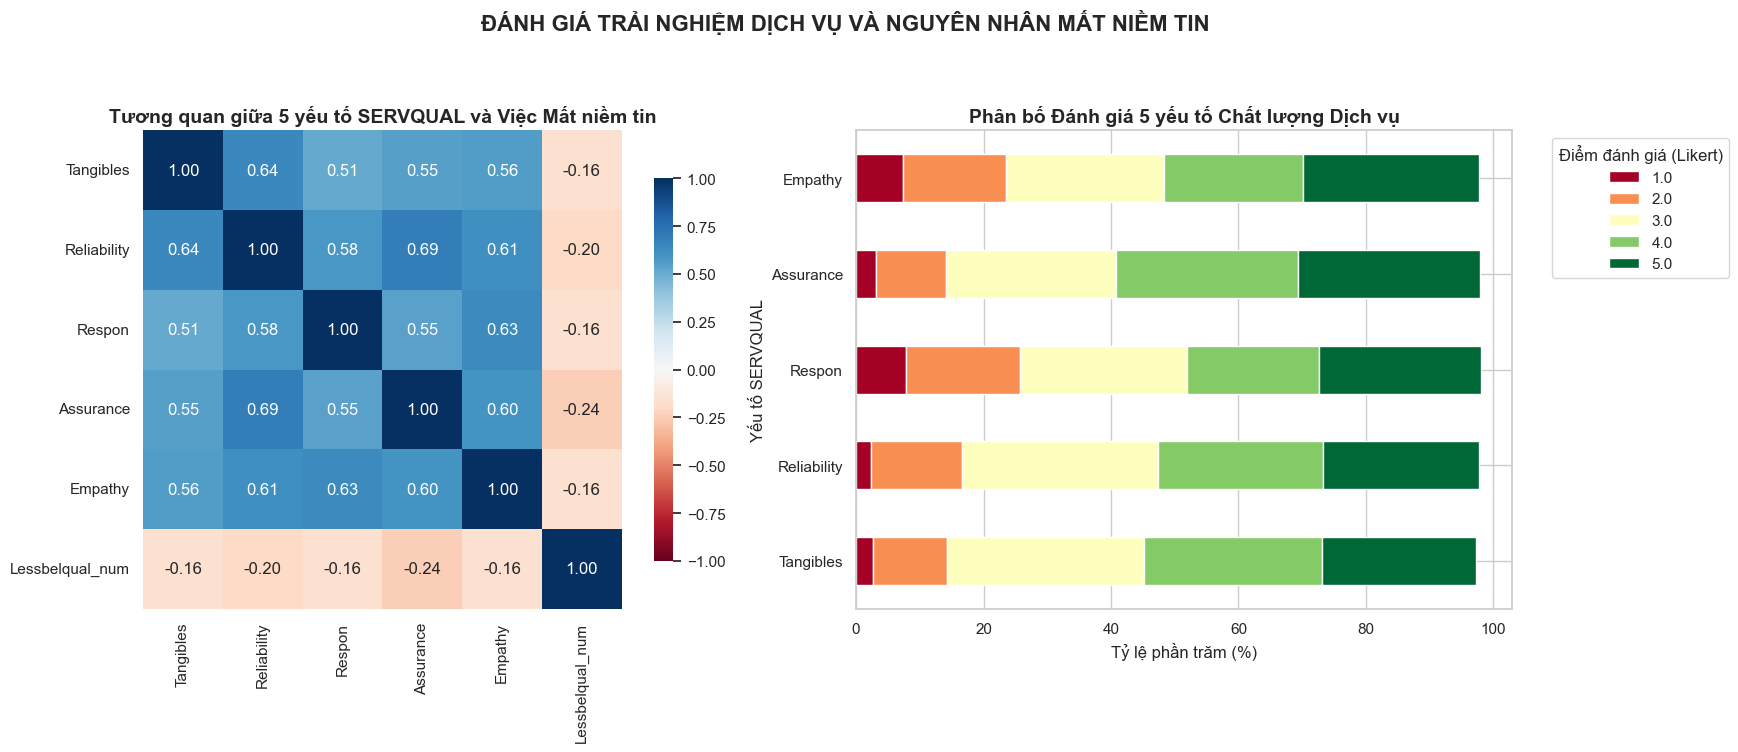

5.1 Tương quan giữa Mất niềm tin (Lessbelqual) và 5 yếu tố (Tương quan âm càng mạnh thì càng dễ mất niềm tin):
Assurance     -0.242787
Reliability   -0.198849
Tangibles     -0.159137
Respon        -0.158294
Empathy       -0.157437
Name: Lessbelqual_num, dtype: float64

5.2 Tỷ lệ % đánh giá (Likert 1-5) của các yếu tố chất lượng dịch vụ:
              1.0    2.0    3.0    4.0    5.0
Tangibles    2.66  11.61  30.90  27.95  24.23
Reliability  2.32  14.31  30.80  25.82  24.56
Respon       7.88  17.89  26.16  20.70  25.39
Assurance    3.19  10.88  26.69  28.63  28.58
Empathy      7.40  16.20  24.76  21.71  27.66

Số lượng người có mất niềm tin vào chất lượng y tế (Lessbelqual):
Lessbelqual
no     1514
yes     554
Name: count, dtype: int64


In [25]:
# --- 9. Tại sao họ mất niềm tin? (Mô hình SERVQUAL) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

servqual_cols = ["Tangibles", "Reliability", "Respon", "Assurance", "Empathy"]

# 1. Chuyển biến Lessbelqual (yes/no) sang số (1/0) để tính tương quan
# Nếu Lessbelqual = 'yes' -> 1 (Mất niềm tin), 'no' -> 0 (Vẫn tin tưởng)
df["Lessbelqual_num"] = (
    df["Lessbelqual"].astype(str).str.lower().map({"yes": 1, "no": 0})
)

# 2. Tính ma trận tương quan (Dùng phương pháp Spearman chuẩn cho dữ liệu Likert 1-5)
corr_cols = servqual_cols + ["Lessbelqual_num"]
corr_matrix = df[corr_cols].corr(method="spearman")

# Tạo khung vẽ
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    "ĐÁNH GIÁ TRẢI NGHIỆM DỊCH VỤ VÀ NGUYÊN NHÂN MẤT NIỀM TIN",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)

# Biểu đồ 1: Heatmap Ma trận tương quan
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    ax=axes[0],
    cbar_kws={"shrink": 0.8},
    square=True,
)
axes[0].set_title(
    "Tương quan giữa 5 yếu tố SERVQUAL và Việc Mất niềm tin",
    fontsize=14,
    fontweight="bold",
)

# Biểu đồ 2: 100% Stacked Bar Chart cho điểm Likert
# Tính tỷ lệ % cho các mức điểm từ 1 đến 5
likert_data = (
    pd.DataFrame(
        {col: df[col].value_counts(normalize=True) * 100 for col in servqual_cols}
    )
    .fillna(0)
    .T
)
# Đảm bảo có đủ 5 cột điểm (1,2,3,4,5)
for i in range(1, 6):
    if i not in likert_data.columns:
        likert_data[i] = 0.0
likert_data = likert_data[[1, 2, 3, 4, 5]]

# Màu sắc: Đỏ (1) -> Xanh (5)
likert_data.plot(
    kind="barh", stacked=True, colormap="RdYlGn", ax=axes[1], edgecolor="white"
)
axes[1].set_title(
    "Phân bố Đánh giá 5 yếu tố Chất lượng Dịch vụ", fontsize=14, fontweight="bold"
)
axes[1].set_xlabel("Tỷ lệ phần trăm (%)")
axes[1].set_ylabel("Yếu tố SERVQUAL")
axes[1].legend(
    title="Điểm đánh giá (Likert)", bbox_to_anchor=(1.05, 1), loc="upper left"
)

plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ĐỂ NHẬN XÉT ---
print(
    "5.1 Tương quan giữa Mất niềm tin (Lessbelqual) và 5 yếu tố (Tương quan âm càng mạnh thì càng dễ mất niềm tin):"
)
corr_with_lessbelqual = (
    corr_matrix["Lessbelqual_num"].drop("Lessbelqual_num").sort_values()
)
print(corr_with_lessbelqual)

print("\n5.2 Tỷ lệ % đánh giá (Likert 1-5) của các yếu tố chất lượng dịch vụ:")
print(likert_data.round(2))

print("\nSố lượng người có mất niềm tin vào chất lượng y tế (Lessbelqual):")
print(df["Lessbelqual"].value_counts())


#### Nhận xét:
**5.1. Bức tranh tổng quan: Cuộc khủng hoảng niềm tin ngầm**  
Dữ liệu chỉ ra một thực trạng đáng báo động đối với hệ thống y tế: Có tới 554 người (chiếm 26.8%) khẳng định họ mất niềm tin vào chất lượng dịch vụ y tế (Lessbelqual = yes). Việc cứ 4 người lại có hơn 1 người hoài nghi về chất lượng khám chữa bệnh là một rào cản khổng lồ, giải thích vì sao dù có bảo hiểm y tế hay được hỗ trợ tiền (như phân tích ở Phần 4), nhiều người vẫn chần chừ không muốn đến bệnh viện.

**5.2. Truy tìm nguyên nhân gốc rễ: Chuyên môn là "Mỏ neo" của niềm tin**  
Ma trận tương quan Spearman đã giải mã chính xác yếu tố nào tác động mạnh nhất đến việc bệnh nhân mất niềm tin (tương quan âm càng lớn, tác động càng mạnh):

- Sự đảm bảo về chuyên môn (Assurance) và Độ tin cậy (Reliability) đứng đầu: Trái với giả thuyết ban đầu cho rằng thái độ (Empathy) hay cơ sở vật chất (Tangibles) là quan trọng nhất, dữ liệu chỉ ra Assurance (-0.24) và Reliability (-0.20) mới là hai yếu tố mang tính "sống còn".

	+ Liên hệ thực tế: Bệnh nhân đi khám bệnh không giống như đi ăn nhà hàng hay nghỉ dưỡng. Sinh mạng và sức khỏe là trên hết. Dù phòng khám có đẹp đến mấy, bác sĩ có nói ngọt ngào đến đâu, nhưng nếu chẩn đoán sai, năng lực yếu kém hoặc kê đơn không hiệu quả (thiếu Assurance & Reliability), bệnh nhân sẽ lập tức quay lưng và mất niềm tin hoàn toàn.

- Cơ sở vật chất, Độ phản hồi và Thái độ (Tangibles, Respon, Empathy) xếp sau: Các yếu tố này có độ tương quan khá đồng đều ở mức thấp hơn (-0.15). Điều này khẳng định quy luật: Bệnh nhân có thể du di cho việc bệnh viện đông đúc, cơ sở vật chất cũ kỹ hay bác sĩ hơi cáu gắt, miễn là họ được chữa khỏi bệnh.

**5.3. Nhận diện "Điểm nghẽn" dịch vụ thực tế (Phân tích phân bố điểm Likert)**
Mặc dù Assurance là yếu tố quyết định niềm tin cốt lõi, nhưng khi nhìn vào phổ điểm đánh giá thực tế (Likert 1-5), chúng ta lại phát hiện ra những "nỗi đau" nhức nhối khác trong khâu vận hành y tế:

- Khủng hoảng về Tốc độ và Thái độ: Hai yếu tố nhận về lượng đánh giá tiêu cực (điểm 1 và 2) cao nhất chính là Sự phản hồi/Nhanh chóng (Respon) với 25.77% và Sự thấu cảm/Thái độ (Empathy) với 23.6%.

	- Liên hệ thực tế: Đây chính là bức tranh phản chiếu tình trạng quá tải tại các bệnh viện tuyến công lập ở Việt Nam hiện nay. Bệnh nhân phải lấy số từ tờ mờ sáng, chờ đợi mòn mỏi nhiều tiếng đồng hồ chỉ để khám 5 phút (Respon thấp). Đồng thời, áp lực quá tải khiến đội ngũ y bác sĩ kiệt sức, dẫn đến thái độ giao tiếp lạnh nhạt, thiếu sự động viên, chia sẻ với người bệnh (Empathy thấp).

- Sự ổn định của Cơ sở vật chất (Tangibles): Điểm đánh giá cho cơ sở vật chất chủ yếu tập trung ở mức 3 và 4 (chiếm gần 60%). Điều này cho thấy hệ thống trang thiết bị y tế cơ bản đã đáp ứng được kỳ vọng trung bình của người dân, không phải là "điểm nghẽn" chính.

***$\Rightarrow$ Dữ liệu đã vẽ ra một chiến lược định vị rõ ràng cho các cơ sở y tế dự phòng và phòng khám tư nhân:***

***1. Giá trị cốt lõi: Phải tập trung xây dựng đội ngũ bác sĩ có chuyên môn cao, minh bạch trong chẩn đoán để giữ vững "Mỏ neo niềm tin" (Assurance & Reliability).***

***2. Lợi thế cạnh tranh: Để thu hút nhóm khách hàng lười đi khám, các cơ sở không cần đầu tư cơ sở vật chất (Tangibles) quá xa hoa lãng phí. Thay vào đó, hãy giải quyết triệt để "nỗi đau" về thời gian chờ đợi (Respon) thông qua công nghệ đặt lịch, và đào tạo kỹ năng giao tiếp thấu cảm (Empathy) cho nhân viên y tế.***

# PHẦN 6: ĐÁNH GIÁ "NĂNG LỰC TIẾP NHẬN THÔNG TIN Y TẾ"

### PHẦN 6.1 - ĐÁNH GIÁ CHẤT LƯỢNG THÔNG TIN THEO HỌC VẤN

***Mục tiêu: Vẽ biểu đồ mạng nhện (Radar Chart) so sánh điểm trung bình của 4 tiêu chí truyền đạt thông tin (SuffInfo, AttractInfo, ImpressInfo, PopularInfo) theo 4 nhóm học vấn.***

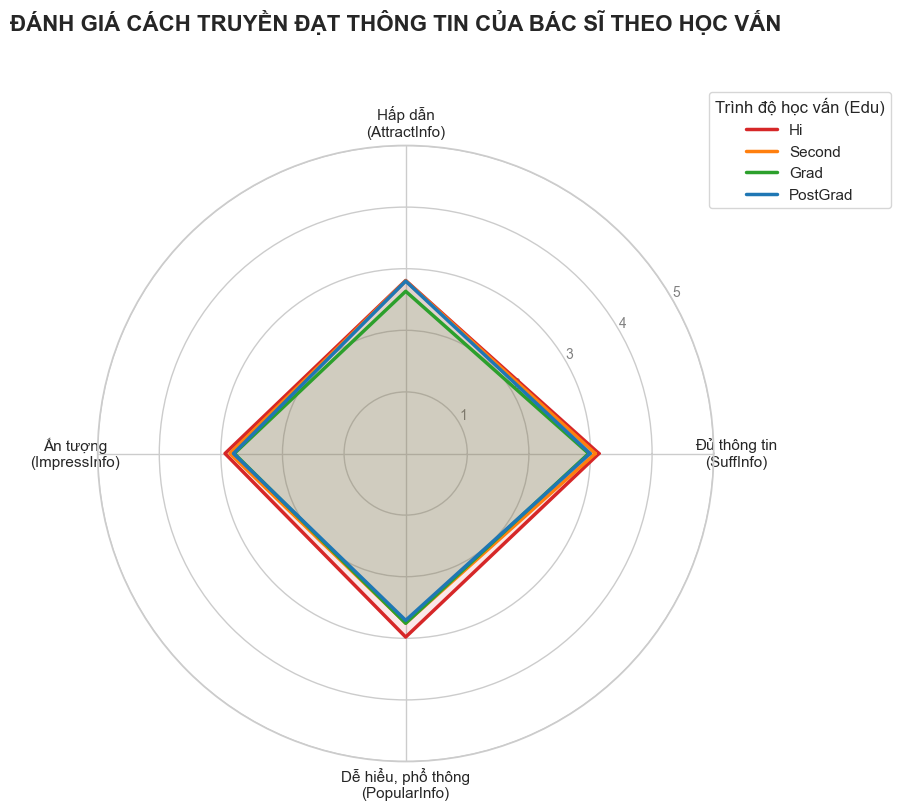

6.1 Điểm trung bình đánh giá thông tin y tế theo Học vấn (Thang 1-5):
     Edu  SuffInfo  AttractInfo  ImpressInfo  PopularInfo
      Hi  3.137019     2.808894     2.932692     2.979567
  Second  3.077465     2.802817     2.852113     2.753521
    Grad  2.970354     2.633406     2.782213     2.755748
PostGrad  2.992126     2.799213     2.795276     2.708661


In [26]:
from math import pi
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 10. Đánh giá chất lượng thông tin phòng khám truyền tải ---
info_cols = ["SuffInfo", "AttractInfo", "ImpressInfo", "PopularInfo"]
edu_order = ["Hi", "Second", "Grad", "PostGrad"]

# Tính điểm trung bình của 4 tiêu chí theo từng nhóm Học vấn
radar_data_edu = df.groupby("Edu")[info_cols].mean().reset_index()

# Ép kiểu Categorical để sắp xếp đúng thứ tự học vấn từ thấp đến cao
radar_data_edu["Edu"] = pd.Categorical(
    radar_data_edu["Edu"], categories=edu_order, ordered=True
)
radar_data_edu = radar_data_edu.sort_values("Edu")

# Chuẩn bị dữ liệu vẽ Radar Chart
categories = info_cols
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Nối vòng

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle(
    "ĐÁNH GIÁ CÁCH TRUYỀN ĐẠT THÔNG TIN CỦA BÁC SĨ THEO HỌC VẤN",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)

colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]  # Đỏ, Cam, Xanh lá, Xanh dương
for i, row in radar_data_edu.iterrows():
    values = row[categories].tolist()
    values += values[:1]
    # Lấy index màu theo thứ tự edu_order
    idx = edu_order.index(row["Edu"]) if row["Edu"] in edu_order else i
    ax.plot(
        angles,
        values,
        linewidth=2.5,
        linestyle="solid",
        label=row["Edu"],
        color=colors[idx],
    )
    ax.fill(angles, values, color=colors[idx], alpha=0.1)

# Định dạng trục
plt.xticks(
    angles[:-1],
    [
        "Đủ thông tin\n(SuffInfo)",
        "Hấp dẫn\n(AttractInfo)",
        "Ấn tượng\n(ImpressInfo)",
        "Dễ hiểu, phổ thông\n(PopularInfo)",
    ],
    size=11,
)
ax.set_rlabel_position(30)
plt.yticks([1, 2, 3, 4, 5], ["1", "2", "3", "4", "5"], color="grey", size=10)
plt.ylim(0, 5)  # Thang điểm Likert từ 1 đến 5
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), title="Trình độ học vấn (Edu)")
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ---
print("6.1 Điểm trung bình đánh giá thông tin y tế theo Học vấn (Thang 1-5):")
print(radar_data_edu.to_string(index=False))


#### Nhận xét:

**6.1. Nghịch lý Học vấn: Học càng cao, đánh giá càng thấp**  
Phân tích điểm trung bình của 4 tiêu chí truyền đạt thông tin (Thang điểm 1-5) theo từng nhóm học vấn đã phơi bày một nghịch lý rất đáng suy ngẫm trong khâu giao tiếp y khoa:

- Sự dễ dãi của nhóm phổ thông: Trái với giả thuyết ban đầu (cho rằng người học vấn thấp sẽ khó hiểu lời bác sĩ nói nhất), dữ liệu lại chỉ ra nhóm học vấn Cấp 2 (Hi) là những người chấm điểm cao nhất ở tất cả các tiêu chí: SuffInfo (3.13) và PopularInfo (2.97).

	- *Giải thích tâm lý: Nhóm người lao động/học vấn phổ thông thường có tâm lý tôn trọng tuyệt đối quyền uy y khoa ("bác sĩ bảo sao nghe vậy"). Kỳ vọng của họ về thông tin rất đơn giản: chỉ cần biết bệnh gì và uống thuốc gì là đủ. Do đó, họ dễ dàng cảm thấy thông tin như vậy là đã "đầy đủ và dễ hiểu".*

- Sự khắt khe của tầng lớp tri thức: Ngược lại, nhóm Đại học (Grad) và Sau Đại học (PostGrad) lại là những người "chấm điểm" bác sĩ thấp nhất, đặc biệt là sự phàn nàn về tính hấp dẫn của thông tin (AttractInfo chạm đáy ở mức 2.63 đối với nhóm Grad).

	- *Giải thích tâm lý: Nhóm tri thức có tư duy phản biện cao. Khi mắc bệnh, họ không chỉ muốn nhận một tờ đơn thuốc vô hồn, mà họ khao khát được biết tại sao mình mắc bệnh, cơ chế hoạt động của thuốc là gì, và các rủi ro dài hạn. Cách giải thích qua loa, rập khuôn của bác sĩ khiến nhóm này cảm thấy thông tin cực kỳ nhàm chán, thiếu chiều sâu (SuffInfo thấp) và không thỏa mãn được trí tò mò khoa học của họ.*

**Liên hệ thực tế: Hội chứng "Khám bệnh 3 phút" và Ngôn ngữ ngoài hành tinh**  
Từ những con số trên, ta thấy rõ "căn bệnh" của truyền thông y tế hiện đại tại các phòng khám:

- Thiếu sự "may đo" (Tailoring): Bác sĩ đang dùng đúng một kịch bản giao tiếp cho mọi loại bệnh nhân. Việc giải thích quá nông sẽ làm phật lòng nhóm trí thức, nhưng nếu dùng từ ngữ quá hàn lâm (tiếng Latin/Anh chuyên ngành) lại khiến thông tin mất đi tính đại chúng (PopularInfo dao động ở mức rất thấp 2.7 - 2.9 trên toàn tập).

- Khủng hoảng thời gian giao tiếp: Do áp lực quá tải (đã chứng minh ở biến Respon Phần 5), các cuộc tư vấn thường bị rút ngắn tối đa (chỉ còn 3-5 phút). Bác sĩ không có thời gian để sử dụng hình ảnh trực quan, mô hình hay câu chuyện ví von, dẫn đến thông tin truyền đạt cực kỳ khô khan, không hề để lại ấn tượng (ImpressInfo < 2.9).

***$\Rightarrow$ Chất lượng khám bệnh tốt chữa được thể xác, nhưng chất lượng giao tiếp mới chữa được tâm lý và giữ chân bệnh nhân. Để thúc đẩy người dân chủ động đi khám định kỳ, các phòng khám cần thay đổi chiến lược truyền thông: Chuyển từ "Thông báo y lệnh" sang "Kể chuyện y khoa" (Medical Storytelling). * Đối với người lớn tuổi/lao động: Dùng hình ảnh, ví dụ đời thường để giải thích.***

***Đối với dân văn phòng/trí thức: Cung cấp thêm cẩm nang số, biểu đồ cảnh báo sức khỏe chi tiết qua email/app để họ tự nghiên cứu thêm***

### PHẦN 6.2 - MỨC ĐỘ QUAN TÂM TIN TỨC Y TẾ

***Mục tiêu: Xem tỷ lệ người chủ động theo dõi tin tức sức khỏe (FlwHealth), và phân tích chéo xem nhóm có theo dõi tin tức thì tỷ lệ đi khám định kỳ (RecPerExam) có cao hơn không.***

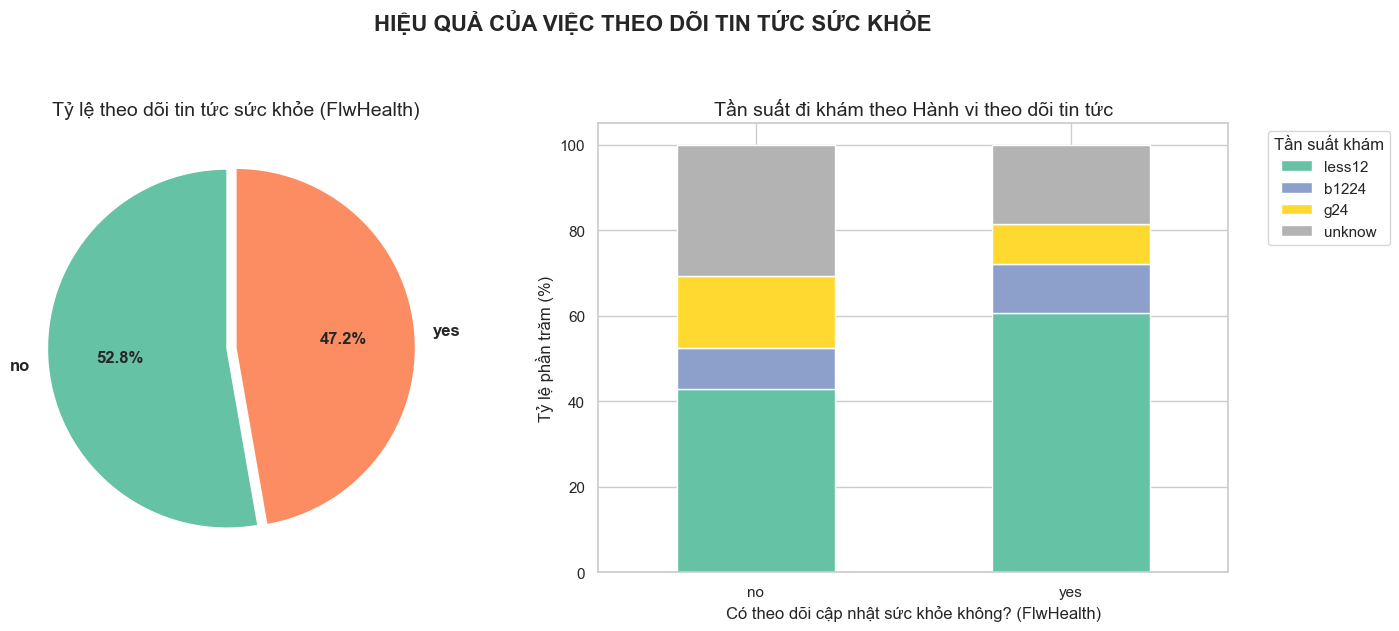

6.2 Tỷ lệ phần trăm Tần suất khám theo việc theo dõi tin tức (FlwHealth):
RecPerExam  less12  b1224    g24  unknow
FlwHealth                               
no           42.80   9.62  16.96   30.61
yes          60.59  11.57   9.21   18.63

Số lượng người theo dõi tin tức y tế thực tế:
FlwHealth
no     1091
yes     977
Name: count, dtype: int64


In [27]:
# --- 11. Mức độ quan tâm tin tức y tế (FlwHealth) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "HIỆU QUẢ CỦA VIỆC THEO DÕI TIN TỨC SỨC KHỎE",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)

# Biểu đồ 1: Pie Chart - Tỷ lệ người theo dõi tin tức y tế
flw_counts = df["FlwHealth"].value_counts()
axes[0].pie(
    flw_counts,
    labels=flw_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66c2a5", "#fc8d62"],
    explode=(0.05, 0),
    textprops={"fontsize": 12, "weight": "bold"},
)
axes[0].set_title("Tỷ lệ theo dõi tin tức sức khỏe (FlwHealth)", fontsize=14)

# Biểu đồ 2: 100% Stacked Bar Chart - Đối chiếu FlwHealth và Hành vi khám (RecPerExam)
rec_order = ["less12", "b1224", "g24", "unknow"]
cross_flw = (
    pd.crosstab(df["FlwHealth"], df["RecPerExam"], normalize="index")[rec_order] * 100
)

cross_flw.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Tần suất đi khám theo Hành vi theo dõi tin tức", fontsize=14)
axes[1].set_ylabel("Tỷ lệ phần trăm (%)")
axes[1].set_xlabel("Có theo dõi cập nhật sức khỏe không? (FlwHealth)")
axes[1].legend(title="Tần suất khám", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ---
print("6.2 Tỷ lệ phần trăm Tần suất khám theo việc theo dõi tin tức (FlwHealth):")
print(cross_flw.round(2))
print("\nSố lượng người theo dõi tin tức y tế thực tế:")
print(flw_counts)


#### Nhận xét:
**Phân tích Hiệu quả của việc theo dõi tin tức sức khỏe (FlwHealth)**  
Việc đánh giá mức độ quan tâm đến tin tức y tế đã mang lại những phát hiện rất rõ ràng về mối tương quan giữa "Tiêu thụ thông tin" và "Hành động thực tế":

- Sự phân hóa 50/50 trong cộng đồng: Tập dữ liệu chia làm hai nửa gần như tương đương: 1,091 người (khoảng 52.8%) hoàn toàn thờ ơ với các tin tức y tế (no), trong khi 977 người (47.2%) có thói quen theo dõi cập nhật sức khỏe thường xuyên (yes). Tỷ lệ 52.8% "mù thông tin y tế chủ động" này chính là nguồn cơn giải thích cho việc tại sao tỷ lệ khám thụ động lại cao đến vậy ở Phần 2.

- Quyền năng của "Ám thị tâm lý" (Psychological Priming): Dữ liệu chứng minh rằng việc tiếp xúc thường xuyên với thông tin y tế tạo ra một lực đẩy hành vi cực kỳ mạnh mẽ.

	- Nhóm có theo dõi tin tức (yes) sở hữu tỷ lệ đi khám định kỳ dưới 12 tháng (less12) đạt mức ấn tượng 60.59%.

	- Ngược lại, ở nhóm không quan tâm tin tức (no), tỷ lệ này rớt xuống chỉ còn 42.80%.

	- Giải thích nguyên nhân: Việc liên tục đọc các bản tin về dịch bệnh, các ca bệnh trẻ hóa, hay các bài báo về dinh dưỡng đóng vai trò như một hệ thống "nhắc nhở ngầm". Nó tạo ra một sự cảnh giác y khoa (healthy fear) cần thiết, thúc đẩy người dân chủ động đi tầm soát thay vì đợi nước đến chân mới nhảy.

- Hậu quả của sự "Cách ly thông tin": Nhóm không theo dõi tin tức (no) đang rơi vào tình trạng bỏ bê y tế nghiêm trọng. Có tới gần 48% số người trong nhóm này đã trên 2 năm không đi khám (g24 - 16.96%) hoặc không nhớ nổi lần cuối đi khám (unknow - 30.61%). Khi không có luồng thông tin nào cảnh báo, sức khỏe tự động bị đẩy xuống cuối danh sách ưu tiên của họ.

**Tiểu kết 6.2 & Ý nghĩa cho Mô hình (Business Insight):**

1. **Giá trị với Machine Learning**: Nếu ở Phần 2, ta thấy có một "khoảng trống" lớn giữa việc mồm nói ưu tiên sức khỏe (HthyPriority) nhưng thực tế không đi khám; thì ở đây, hành vi tiêu thụ thông tin (FlwHealth) lại có tính đồng nhất rất cao với hành vi đi khám. Do đó, FlwHealth sẽ là một Đặc trưng (Feature) có trọng số dự báo cực kỳ uy tín cho mô hình AI.

2. **Chiến lược phòng khám**: Đối với các cơ sở y tế, Marketing nội dung (Content Marketing) không chỉ để làm thương hiệu, mà nó thực sự tạo ra "tỷ lệ chuyển đổi" (Conversion rate) thành lượt đến khám. Các phòng khám cần xây dựng kênh Zalo OA, Fanpage hoặc Email Newsletter cung cấp kiến thức sức khỏe định kỳ cho bệnh nhân cũ. Khi thông tin y tế "chạm" đến họ mỗi tuần, xác suất họ quay lại khám định kỳ sẽ tăng lên đáng kể.

# PHẦN 7: ẢNH HƯỞNG CỦA MÔI TRƯỜNG, GIA ĐÌNH & THÓI QUEN

***Mục tiêu: chúng ta sẽ kiểm tra xem liệu việc sở hữu một "hệ sinh thái y tế thu nhỏ" tại nhà (có tủ thuốc MedCabinet, có máy đo huyết áp/cân nặng ExamTools) và thói quen từ gia đình (Habit) có biến một người lười thành một người chăm đi khám hay không.***

### 7.1 TỦ THUỐC TẠI NHÀ (MedCabinet) và DỤNG CỤ Y TẾ TẠI NHÀ (ExamTools)

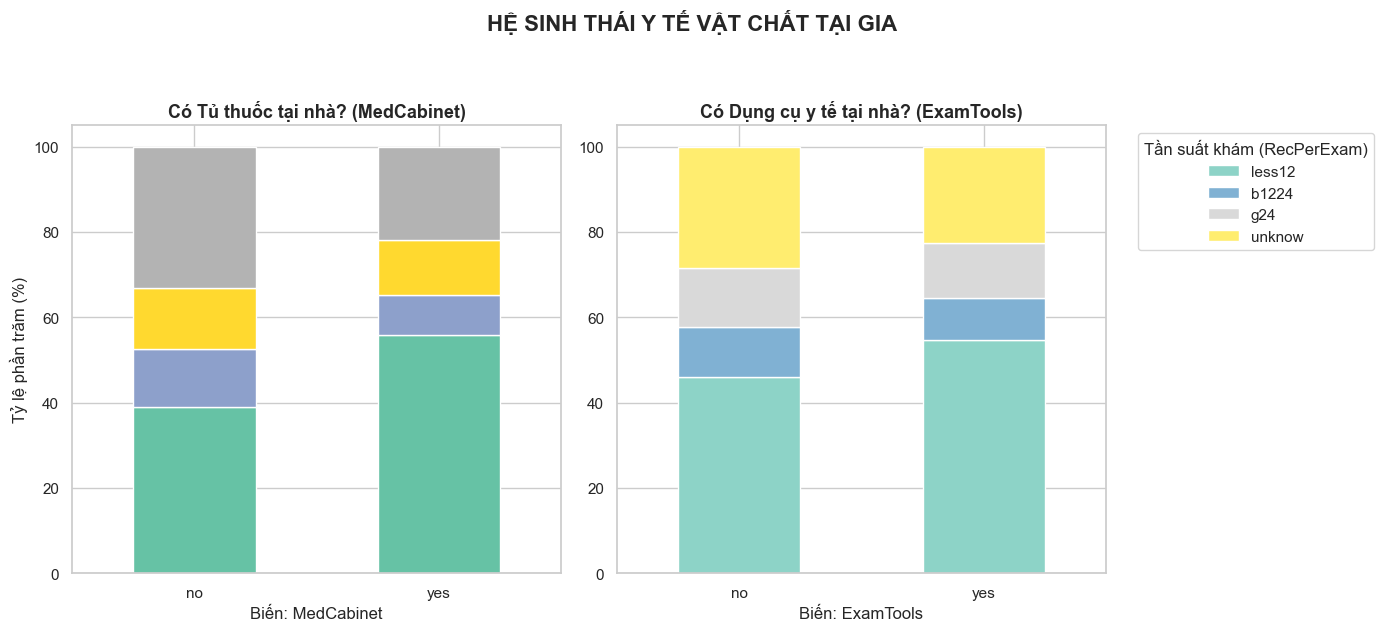

7.1 Tỷ lệ % Tần suất khám theo việc sở hữu TỦ THUỐC (MedCabinet):
RecPerExam  less12  b1224    g24  unknow
MedCabinet                              
no           38.96  13.64  14.18   33.21
yes          55.72   9.40  12.97   21.91

Số lượng thực tế (MedCabinet):
MedCabinet
yes    1511
no      557
Name: count, dtype: int64
------------------------------------------------------------
7.2 Tỷ lệ % Tần suất khám theo việc sở hữu DỤNG CỤ Y TẾ (ExamTools):
RecPerExam  less12  b1224    g24  unknow
ExamTools                               
no           46.00  11.74  13.68   28.57
yes          54.67   9.74  13.04   22.54

Số lượng thực tế (ExamTools):
ExamTools
yes    1242
no      826
Name: count, dtype: int64


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

rec_order = ["less12", "b1224", "g24", "unknow"]

# --- CELL 14.1: HỆ SINH THÁI Y TẾ TẠI GIA (MedCabinet, ExamTools) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "HỆ SINH THÁI Y TẾ VẬT CHẤT TẠI GIA", fontsize=16, fontweight="bold", y=1.05
)

vars_1 = ["MedCabinet", "ExamTools"]
titles_1 = ["Có Tủ thuốc tại nhà? (MedCabinet)", "Có Dụng cụ y tế tại nhà? (ExamTools)"]
colors_1 = ["Set2", "Set3"]

for i, var in enumerate(vars_1):
    # Tính tỷ lệ % chéo để chuẩn hóa về 100%
    cross_tab = pd.crosstab(df[var], df["RecPerExam"], normalize="index")

    # Reindex để đảm bảo đúng thứ tự
    if set(rec_order).issubset(cross_tab.columns):
        cross_tab = cross_tab[rec_order] * 100
    else:
        cross_tab = cross_tab * 100

    # Vẽ biểu đồ Stacked Bar
    cross_tab.plot(
        kind="bar", stacked=True, ax=axes[i], colormap=colors_1[i], edgecolor="white"
    )
    axes[i].set_title(titles_1[i], fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Tỷ lệ phần trăm (%)" if i == 0 else "")
    axes[i].set_xlabel(f"Biến: {var}")
    axes[i].tick_params(axis="x", rotation=0)

    # Chỉ giữ lại chú thích (legend) ở biểu đồ thứ 2
    if i == 1:
        axes[i].legend(
            title="Tần suất khám (RecPerExam)",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ĐỂ NHẬN XÉT ---
print("7.1 Tỷ lệ % Tần suất khám theo việc sở hữu TỦ THUỐC (MedCabinet):")
print(
    (
        pd.crosstab(df["MedCabinet"], df["RecPerExam"], normalize="index")[rec_order]
        * 100
    ).round(2)
)
print("\nSố lượng thực tế (MedCabinet):")
print(df["MedCabinet"].value_counts())
print("-" * 60)

print("7.2 Tỷ lệ % Tần suất khám theo việc sở hữu DỤNG CỤ Y TẾ (ExamTools):")
print(
    (
        pd.crosstab(df["ExamTools"], df["RecPerExam"], normalize="index")[rec_order]
        * 100
    ).round(2)
)
print("\nSố lượng thực tế (ExamTools):")
print(df["ExamTools"].value_counts())


#### Nhận xét:
Việc trang bị các vật dụng y tế cơ bản tại nhà đóng vai trò như những "lời nhắc nhở trực quan" (visual cues) kích thích hành vi y tế của người dân:

- **Tủ thuốc gia đình (MedCabinet)**: Những người có chuẩn bị tủ thuốc tại nhà cho thấy sự chủ động vượt trội. Tỷ lệ đi khám định kỳ dưới 12 tháng (less12) ở nhóm này đạt 55.72%, cao hơn rất nhiều so với nhóm không có tủ thuốc (38.96%). Đồng thời, việc "không nhớ lần cuối đi khám" (unknow) ở nhóm có tủ thuốc cũng giảm mạnh từ 33.21% xuống chỉ còn 21.91%.

- **Dụng cụ y tế (ExamTools)**: Tương tự, việc sở hữu các thiết bị như máy đo huyết áp, nhiệt kế, cân điện tử cũng tạo ra sự khác biệt tích cực (54.67% chủ động khám so với 46.00% ở nhóm không có).

- *Ý nghĩa hành vi*: Những người mua sắm thiết bị y tế tại gia vốn đã có sẵn nền tảng ý thức phòng bệnh cao. Khi tự đo các chỉ số tại nhà và phát hiện sự bất thường nhỏ, họ sẽ có xu hướng đi gặp bác sĩ ngay lập tức để xác nhận, thay vì chần chừ cho đến khi phát bệnh nặng.

### 7.2 THÓI QUEN GIA ĐÌNH (Habit)

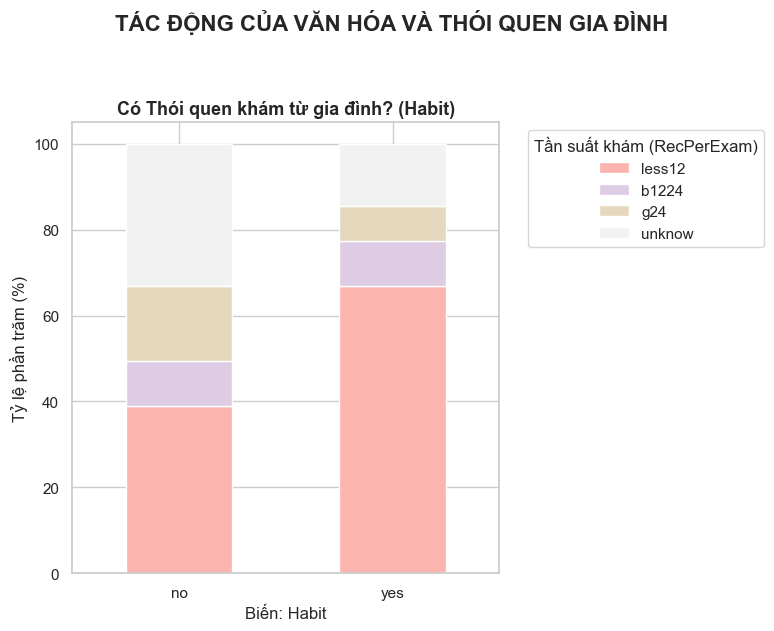

7.3 Tỷ lệ % Tần suất khám theo THÓI QUEN GIA ĐÌNH (Habit):
RecPerExam  less12  b1224    g24  unknow
Habit                                   
no           38.86  10.58  17.35   33.22
yes          66.78  10.49   8.20   14.54

Số lượng thực tế (Habit):
Habit
no     1153
yes     915
Name: count, dtype: int64


In [29]:
# --- CELL 14.2: THÓI QUEN GIA ĐÌNH (Habit) ---
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(
    "TÁC ĐỘNG CỦA VĂN HÓA VÀ THÓI QUEN GIA ĐÌNH", fontsize=16, fontweight="bold", y=1.05
)

cross_tab_habit = pd.crosstab(df["Habit"], df["RecPerExam"], normalize="index")
if set(rec_order).issubset(cross_tab_habit.columns):
    cross_tab_habit = cross_tab_habit[rec_order] * 100
else:
    cross_tab_habit = cross_tab_habit * 100

cross_tab_habit.plot(
    kind="bar", stacked=True, ax=ax, colormap="Pastel1", edgecolor="white"
)
ax.set_title("Có Thói quen khám từ gia đình? (Habit)", fontsize=13, fontweight="bold")
ax.set_ylabel("Tỷ lệ phần trăm (%)")
ax.set_xlabel("Biến: Habit")
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="Tần suất khám (RecPerExam)", bbox_to_anchor=(1.05, 1), loc="upper left"
)

plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ĐỂ NHẬN XÉT ---
print("7.3 Tỷ lệ % Tần suất khám theo THÓI QUEN GIA ĐÌNH (Habit):")
print(
    (
        pd.crosstab(df["Habit"], df["RecPerExam"], normalize="index")[rec_order] * 100
    ).round(2)
)
print("\nSố lượng thực tế (Habit):")
print(df["Habit"].value_counts())


#### Nhận xét:
Biến Habit (Thói quen khám bệnh từ gia đình hoặc tổ chức) chính là yếu tố tạo ra sự phân hóa chênh lệch lớn nhất trong toàn bộ các biến môi trường:

- Hiệu ứng "Lây lan hành vi": Nếu một cá nhân được sống trong môi trường mà gia đình hoặc công ty có thói quen đi khám định kỳ (Habit = yes), tỷ lệ chủ động đi khám (less12) của họ chạm mức kỷ lục: 66.78% (cao nhất trong tất cả các nhóm đặc trưng từ đầu đồ án đến giờ). Tỷ lệ lười khám trên 2 năm (g24) của nhóm này chỉ vỏn vẹn 8.20%.

- Lỗ hổng của sự tự giác: Ngược lại, ở những người thiếu đi thói quen này từ tập thể (Habit = no), sự tự giác cá nhân trở nên cực kỳ yếu ớt. Tỷ lệ khám chủ động tụt dốc thảm hại chỉ còn 38.86%, và có tới hơn một nửa nhóm này rơi vào tình trạng bỏ bê y tế (17.35% trên 2 năm không khám và 33.22% không nhớ lần cuối đi khám).

*$\Rightarrow$ Giá trị với Machine Learning: Biến Habit chắc chắn sẽ là một "Super Feature" (Đặc trưng siêu việt) có mức độ đóng góp (Feature Importance) cực cao khi đưa vào huấn luyện mô hình dự đoán. AI sẽ học được quy luật: Nếu không có thói quen từ tập thể/gia đình, xác suất người này lười đi khám là vô cùng lớn.*

*$\Rightarrow$ Chiến lược giải pháp y tế: Dữ liệu đã chứng minh chăm sóc sức khỏe mang tính "bầy đàn" và "gia đình" rất cao. Các phòng khám không nên chỉ truyền thông đến từng cá nhân đơn lẻ, mà phải đánh vào đơn vị gia đình. Việc thiết kế các "Gói khám sức khỏe gia đình" (mua 1 gói tầm soát cho cả bố mẹ và con cái) sẽ hiệu quả hơn nhiều. Khi một người đi khám, họ sẽ kéo theo cả gia đình đi cùng để tạo lập thói quen.*

# PHẦN 8: TÁC ĐỘNG CỦA LỊCH SỬ BỆNH LÝ GIA ĐÌNH & CÁ NHÂN

***Mục tiêu là kiểm chứng xem liệu một "cú sốc tâm lý" (như việc bản thân hoặc người nhà phải điều trị bệnh dài hạn) có tạo ra "Sự thức tỉnh" giúp họ chăm đi khám định kỳ hơn hay không.***

### 8.1 TÁC ĐỘNG TỪ LỊCH SỬ BỆNH LÝ CÁ NHÂN (PerTrmt)

<Figure size 800x600 with 0 Axes>

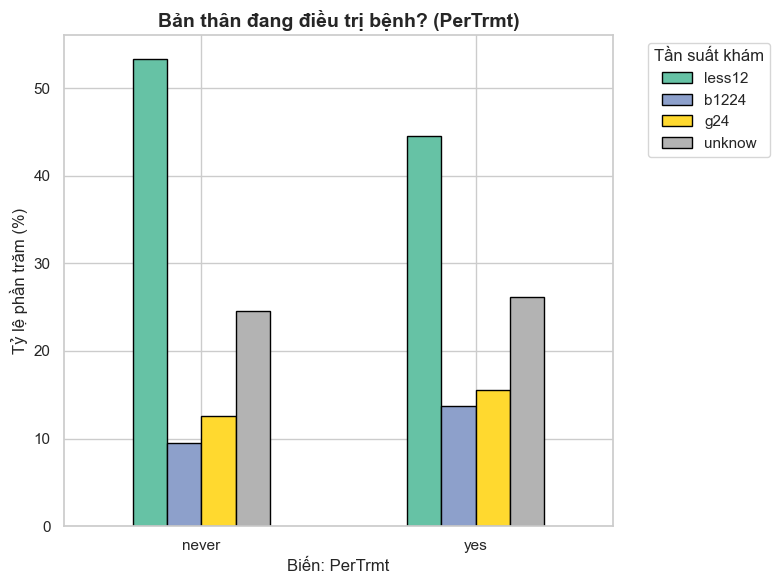

8.1 Tỷ lệ % Tần suất khám theo biến PerTrmt:
RecPerExam  less12  b1224    g24  unknow
PerTrmt                                 
never        53.37   9.49  12.57   24.57
yes          44.60  13.75  15.52   26.13

Số lượng thực tế (PerTrmt):
PerTrmt
never    1559
yes       509
Name: count, dtype: int64


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

rec_order = ["less12", "b1224", "g24", "unknow"]
common_cmap = "Set2"

# --- CELL 15.1: BẢN THÂN ĐANG ĐIỀU TRỊ BỆNH (PerTrmt) ---
var_1 = "PerTrmt"

plt.figure(figsize=(8, 6))
cross_tab_1 = pd.crosstab(df[var_1], df["RecPerExam"], normalize="index")

if set(rec_order).issubset(cross_tab_1.columns):
    cross_tab_1 = cross_tab_1[rec_order] * 100
else:
    cross_tab_1 = cross_tab_1 * 100

cross_tab_1.plot(kind="bar", figsize=(8, 6), colormap=common_cmap, edgecolor="black")
plt.title("Bản thân đang điều trị bệnh? (PerTrmt)", fontsize=14, fontweight="bold")
plt.ylabel("Tỷ lệ phần trăm (%)")
plt.xlabel("Biến: PerTrmt")
plt.xticks(rotation=0)
plt.legend(title="Tần suất khám", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ĐỂ NHẬN XÉT ---
print(f"8.1 Tỷ lệ % Tần suất khám theo biến {var_1}:")
print(cross_tab_1.round(2))
print(f"\nSố lượng thực tế ({var_1}):")
print(df[var_1].value_counts())


#### Nhận xét:
Đối với cá nhân (PerTrmt): Những người đang KHÔNG điều trị bệnh (never) có tỷ lệ đi khám định kỳ dưới 12 tháng (less12) khá cao, đạt 53.37%. Ngược lại, nhóm ĐANG điều trị bệnh dài hạn (yes - 509 người)  lại có tỷ lệ khám tổng quát tụt xuống chỉ còn 44.60%, đồng thời tỷ lệ "bỏ quên" việc khám (>24 tháng hoặc không nhớ) lại tăng lên.

### 8.2 TÁC ĐỘNG TỪ LỊCH SỬ BỆNH LÝ NGƯỜI THÂN (AcqTrmt)

<Figure size 800x600 with 0 Axes>

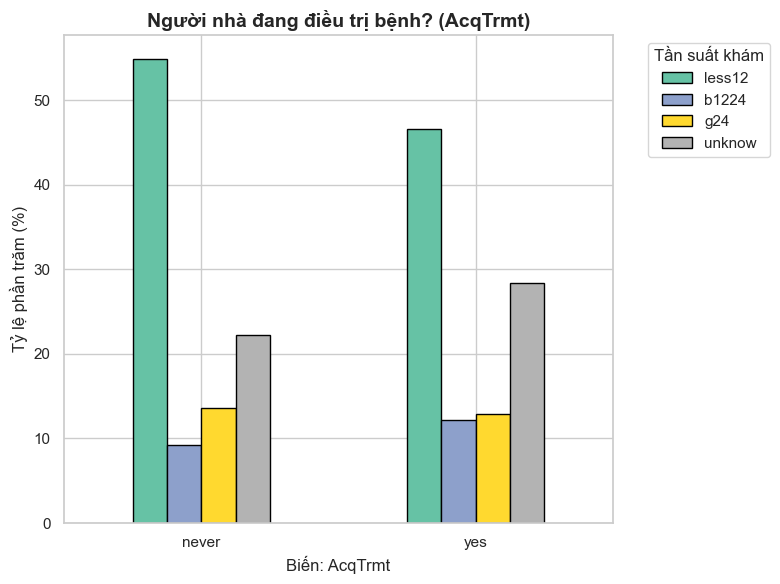

8.2 Tỷ lệ % Tần suất khám theo biến AcqTrmt:
RecPerExam  less12  b1224    g24  unknow
AcqTrmt                                 
never        54.91   9.21  13.64   22.24
yes          46.56  12.21  12.87   28.35

Số lượng thực tế (AcqTrmt):
AcqTrmt
never    1151
yes       917
Name: count, dtype: int64


In [31]:
# --- CELL 15.2: NGƯỜI NHÀ ĐANG ĐIỀU TRỊ BỆNH (AcqTrmt) ---
var_2 = "AcqTrmt"

plt.figure(figsize=(8, 6))
cross_tab_2 = pd.crosstab(df[var_2], df["RecPerExam"], normalize="index")

if set(rec_order).issubset(cross_tab_2.columns):
    cross_tab_2 = cross_tab_2[rec_order] * 100
else:
    cross_tab_2 = cross_tab_2 * 100

cross_tab_2.plot(kind="bar", figsize=(8, 6), colormap=common_cmap, edgecolor="black")
plt.title("Người nhà đang điều trị bệnh? (AcqTrmt)", fontsize=14, fontweight="bold")
plt.ylabel("Tỷ lệ phần trăm (%)")
plt.xlabel("Biến: AcqTrmt")
plt.xticks(rotation=0)
plt.legend(title="Tần suất khám", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ĐỂ NHẬN XÉT ---
print(f"8.2 Tỷ lệ % Tần suất khám theo biến {var_2}:")
print(cross_tab_2.round(2))
print(f"\nSố lượng thực tế ({var_2}):")
print(df[var_2].value_counts())


#### Nhận xét:
Đối với gia đình (AcqTrmt & StabHthStt): Hiện tượng tương tự xảy ra với gia đình. Khi gia đình bình an, không có ai bệnh nặng (AcqTrmt = never), tỷ lệ khám chủ động là 54.91%. Nhưng khi trong nhà có người bệnh dài hạn (AcqTrmt = yes), tỷ lệ người nhà đi khám chủ động lập tức rớt xuống 46.56%. Tương tự, nhóm có sức khỏe gia đình không ổn định (StabHthStt = no)  cũng là nhóm lười đi tầm soát nhất

### 8.3 TÁC ĐỘNG TỪ SỨC KHỎE GIA ĐÌNH NÓI CHUNG (StabHthStt)

<Figure size 800x600 with 0 Axes>

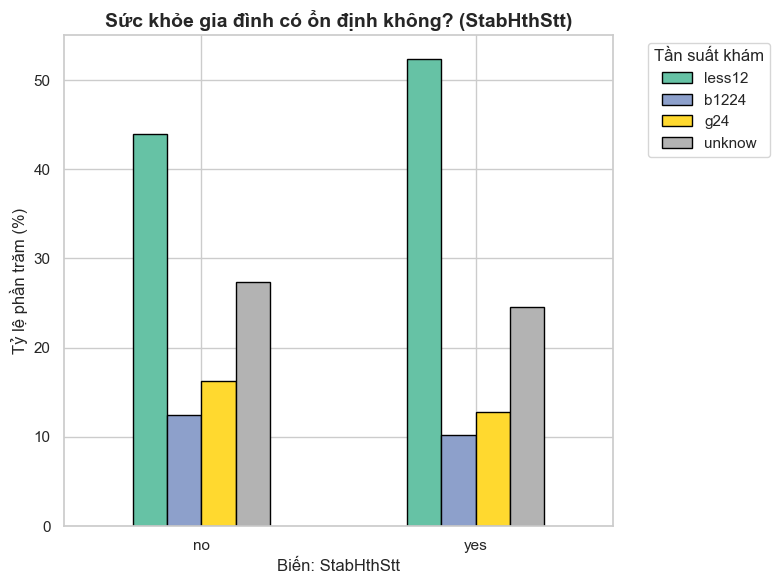

8.3 Tỷ lệ % Tần suất khám theo biến StabHthStt:
RecPerExam  less12  b1224    g24  unknow
StabHthStt                              
no           43.94  12.46  16.26   27.34
yes          52.39  10.23  12.82   24.56

Số lượng thực tế (StabHthStt):
StabHthStt
yes    1779
no      289
Name: count, dtype: int64


In [32]:
# --- CELL 15.3: SỨC KHỎE GIA ĐÌNH ỔN ĐỊNH (StabHthStt) ---
var_3 = "StabHthStt"

plt.figure(figsize=(8, 6))
cross_tab_3 = pd.crosstab(df[var_3], df["RecPerExam"], normalize="index")

if set(rec_order).issubset(cross_tab_3.columns):
    cross_tab_3 = cross_tab_3[rec_order] * 100
else:
    cross_tab_3 = cross_tab_3 * 100

cross_tab_3.plot(kind="bar", figsize=(8, 6), colormap=common_cmap, edgecolor="black")
plt.title(
    "Sức khỏe gia đình có ổn định không? (StabHthStt)", fontsize=14, fontweight="bold"
)
plt.ylabel("Tỷ lệ phần trăm (%)")
plt.xlabel("Biến: StabHthStt")
plt.xticks(rotation=0)
plt.legend(title="Tần suất khám", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ĐỂ NHẬN XÉT ---
print(f"8.3 Tỷ lệ % Tần suất khám theo biến {var_3}:")
print(cross_tab_3.round(2))
print(f"\nSố lượng thực tế ({var_3}):")
print(df[var_3].value_counts())


#### Phân tích Nguyên nhân gốc rễ (Root Cause Analysis)

*Trong bản nội dung dự kiến, chúng ta từng đặt ra "Insight kỳ vọng" rằng: những người có người thân đang điều trị bệnh (AcqTrmt = Yes) sẽ có ý thức tầm soát bệnh cao hơn hẳn do sự thức tỉnh. Tuy nhiên, dữ liệu thực tế lại chứng minh ĐIỀU NGƯỢC LẠI HOÀN TOÀN.*

Tại sao việc chứng kiến người thân đau ốm không làm người ta sợ hãi mà đi khám, trái lại còn làm họ lười đi hơn? Có 3 nguyên nhân cốt lõi giải thích cho nghịch lý này:

1. **Gánh nặng Tài chính và Thời gian (Caregiver Burden)**: Như đã phân tích ở Phần 4, Tiền bạc và Thời gian là hai rào cản lớn nhất. Khi một gia đình có người mắc bệnh mãn tính (ung thư, chạy thận, tiểu đường...), toàn bộ nguồn lực tài chính và quỹ thời gian của cả nhà đều bị hút cạn vào việc "chữa bệnh" cho thành viên đó. Những người khỏe mạnh còn lại buộc phải gác lại nhu cầu "phòng bệnh" (khám tổng quát) của bản thân để nhường nguồn lực cho người đang ốm.

2. **Sự nhầm lẫn giữa "Điều trị chuyên khoa" và "Khám tổng quát"**: Những người đang điều trị bệnh (PerTrmt = yes) thường phải đến viện hàng tháng để lấy thuốc (ví dụ: thuốc huyết áp, tiểu đường). Họ mặc định việc gặp bác sĩ chuyên khoa đó đã là "khám bệnh" rồi, nên họ không chủ động đăng ký các gói "Khám sức khỏe tổng quát định kỳ" (RecPerExam)  nữa. Đây là một lỗ hổng lớn vì khám chuyên khoa không giúp họ tầm soát sớm các bệnh lý ở những cơ quan khác.

3. **Tâm lý chối bỏ và Mệt mỏi y tế (Medical Fatigue)**: Việc ra vào bệnh viện quá nhiều để chăm sóc người thân khiến họ bị ám ảnh, mệt mỏi với môi trường y tế. Kết hợp với rào cản tâm lý DiscDisease (Sợ phát hiện ra bệnh) đã phân tích trước đó, họ nảy sinh tâm lý: "Nhà đã có một người bệnh là quá đủ rồi, thà mình không đi khám để không phải lo nghĩ thêm".

#### Liên hệ thực tế
Thực trạng này phản ánh chính xác bức tranh Y tế cộng đồng tại Việt Nam. Theo các nghiên cứu về "Gánh nặng chi phí y tế thảm họa" (Catastrophic health expenditure), chi phí điều trị các bệnh mãn tính thường đẩy các hộ gia đình vào cảnh khó khăn. Y tế dự phòng (khám sức khỏe định kỳ) vô hình trung trở thành một loại "hàng hóa xa xỉ" (Luxury good) mà chỉ những gia đình có sức khỏe ổn định (StabHthStt = yes) và có kinh tế mới dám chi trả thường xuyên.


**Tiểu kết Phần 8 (Business & AI Insights):**

- **Với Mô hình AI:** Các biến PerTrmt, AcqTrmt, và StabHthStt  sẽ cung cấp tín hiệu ngược: Cứ thấy ai khai đang có người nhà bệnh nặng, AI sẽ đánh dấu người đó vào nhóm "Nguy cơ cao bỏ bê sức khỏe bản thân".

- **Với Chiến lược Kinh doanh (Giải pháp):** Bác bỏ kỳ vọng ban đầu về việc bán "Gói khám gia đình" chung chung. Thay vào đó, phòng khám nên thiết kế "Chính sách trợ giá người nhà" (Caregiver Subsidy/Packages). Ví dụ: Nếu một bệnh nhân đang điều trị tiểu đường tại phòng khám, cơ sở y tế sẽ tặng ngay voucher giảm giá 50% gói khám tổng quát cho vợ/chồng hoặc con cái của bệnh nhân đó. Cách tiếp cận này vừa mang tính nhân văn sâu sắc (giảm gánh nặng tài chính), vừa giải quyết đúng "nỗi đau" (pain points) mà dữ liệu vừa phơi bày.

# PHẦN 9: HÀNH VI ĐỐI PHÓ KHI CÓ TRIỆU CHỨNG (COPING MECHANISM)

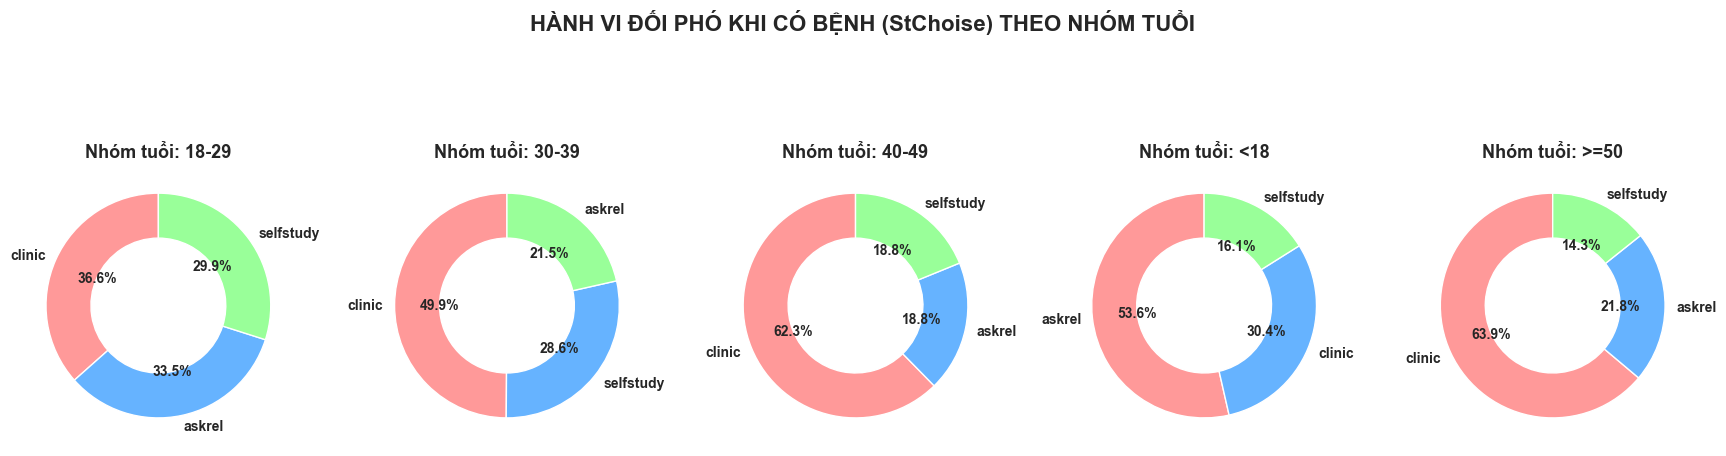

9. Tỷ lệ % Hành vi đối phó (StChoise) theo Nhóm tuổi (Age_gr):
StChoise  askrel  clinic  selfstudy
Age_gr                             
18-29      33.52   36.56      29.92
30-39      21.47   49.90      28.63
40-49      18.83   62.34      18.83
<18        53.57   30.36      16.07
>=50       21.85   63.87      14.29

Số lượng thực tế chi tiết:
StChoise  askrel  clinic  selfstudy
Age_gr                             
18-29        419     457        374
30-39        105     244        140
40-49         29      96         29
<18           30      17          9
>=50          26      76         17


In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# --- CELL 16: HÀNH VI ĐỐI PHÓ KHI CÓ TRIỆU CHỨNG (StChoise) ---
# Lấy danh sách các nhóm tuổi hiện có và sắp xếp
# Chuyển về string để tránh lỗi nếu có giá trị NaN hoặc định dạng lạ
age_groups = sorted([str(x) for x in df["Age_gr"].unique() if pd.notna(x)])
n_groups = len(age_groups)

# Tự động điều chỉnh chiều rộng khung hình dựa trên số lượng nhóm tuổi
fig, axes = plt.subplots(1, n_groups, figsize=(3.5 * n_groups, 5))
fig.suptitle(
    "HÀNH VI ĐỐI PHÓ KHI CÓ BỆNH (StChoise) THEO NHÓM TUỔI",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)

# Nếu chỉ có 1 nhóm tuổi, ép axes thành dạng list để không bị lỗi vòng lặp
if n_groups == 1:
    axes = [axes]

# Bảng màu (Tự động lặp lại nếu có nhiều hơn 3 lựa chọn)
colors = ["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"]

for i, age in enumerate(age_groups):
    # Đếm số lượng các lựa chọn trong từng nhóm tuổi
    subset = df[df["Age_gr"] == age]["StChoise"].value_counts()

    # Vẽ pie chart với thuộc tính wedgeprops (width=0.4) để tạo thành dạng Donut
    axes[i].pie(
        subset,
        labels=subset.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors[: len(subset)],
        wedgeprops=dict(width=0.4, edgecolor="white"),
        textprops={"fontsize": 10, "weight": "bold"},
    )

    axes[i].set_title(f"Nhóm tuổi: {age}", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ĐỂ NHẬN XÉT ---
print("9. Tỷ lệ % Hành vi đối phó (StChoise) theo Nhóm tuổi (Age_gr):")
cross_tab_stchoise = (
    pd.crosstab(df["Age_gr"], df["StChoise"], normalize="index") * 100
).round(2)
print(cross_tab_stchoise)

print("\nSố lượng thực tế chi tiết:")
print(pd.crosstab(df["Age_gr"], df["StChoise"]))


#### Nhận xét:
Phân tích chi tiết: Sự chuyển dịch niềm tin qua các thế hệ
Dữ liệu cho thấy sự khác biệt thế hệ (Generation Gap) cực kỳ rõ rệt trong cách người dân phản ứng với bệnh tật. Niềm tin vào hệ thống y tế tỷ lệ thuận với độ tuổi:

- Nhóm Vị thành niên (<18 tuổi) - Phụ thuộc gia đình: Đúng như đặc điểm tâm lý lứa tuổi, hơn một nửa nhóm này (53.57%) chọn cách hỏi người thân (askrel) khi có triệu chứng. Tỷ lệ tự đến phòng khám hay tự tìm hiểu rất thấp vì họ chưa tự chủ về tài chính và quyết định.

- Nhóm Gen Z & Millennials (18 đến 39 tuổi) - Sự trỗi dậy của "Bác sĩ Google": Đây là điểm nhấn quan trọng nhất. Ở nhóm 18-29 tuổi, tỷ lệ tự nghiên cứu/Google (selfstudy) đạt đỉnh cao nhất với gần 30%, và duy trì ở mức 28.63% đối với nhóm 30-39 tuổi. Đáng báo động hơn, ở nhóm 18-29, tỷ lệ chọn đi phòng khám (clinic - 36.56%) chỉ nhỉnh hơn một chút so với việc hỏi người thân (askrel - 33.52%) hoặc tự lên mạng tra cứu. Hành vi y tế của người trẻ đang cực kỳ phân mảnh và thiếu tính chuyên nghiệp.

- Nhóm Trung niên & Lớn tuổi (>= 40 tuổi) - Niềm tin vào chuyên môn: Khi bước qua tuổi 40, hành vi "tự làm bác sĩ" sụt giảm mạnh (chỉ còn 14-18%). Thay vào đó, tỷ lệ chọn đến thẳng phòng khám/bệnh viện (clinic) tăng vọt lên mức áp đảo: 62.34% (nhóm 40-49) và 63.87% (nhóm >=50).

***Vì sao người trẻ lại thích tự bắt bệnh hơn là đến gặp bác sĩ?***

1. Chủ nghĩa công nghệ & Rào cản thời gian: Thế hệ 18-39 lớn lên cùng Internet. Khi có một triệu chứng, hành vi phản xạ vô điều kiện của họ là gõ vào thanh tìm kiếm. Google trả kết quả trong 0.1 giây, trong khi đến phòng khám phải đối mặt với rào cản Wsttime (Sợ tốn thời gian chờ đợi) đã được chứng minh ở Phần 4.

2. Rào cản tài chính (Wstmon): Nhóm 18-29 (chủ yếu là sinh viên, người mới đi làm) có ngân sách eo hẹp. Tự tra Google và ra hiệu thuốc mua vài liều giảm đau là cách "tối ưu chi phí" ngắn hạn nhất so với việc đóng tiền khám bệnh.

3. Tâm lý chủ quan: Người trẻ thường có niềm tin sai lầm về sức đề kháng của mình. Họ coi các triệu chứng chỉ là "cảm vặt", không đáng để đi viện. Ngược lại, người trên 40 tuổi đã bắt đầu cảm nhận rõ sự suy giảm thể chất nên họ sợ rủi ro và tuân thủ y lệnh hơn.

***Liên hệ thực tế & Hệ lụy y tế***  
Thực trạng dữ liệu này phản ánh một vấn nạn nhức nhối của y tế Việt Nam: Thói quen tự ý mua thuốc và lạm dụng kháng sinh.

- Dẫn chứng: Người trẻ tra Google ra bệnh, sau đó mang kết quả tự chẩn đoán đó ra các nhà thuốc tư nhân để mua thuốc mà không cần kê đơn. Hệ lụy là tình trạng kháng kháng sinh (Antimicrobial resistance) đang ở mức báo động.

- Hội chứng Cyberchondria: Việc tự tìm hiểu (selfstudy) thường dẫn đến "Cyberchondria" - hội chứng lo âu bệnh tật do đọc thông tin y tế trên mạng. Ví dụ: Chỉ bị đau đầu do căng thẳng, nhưng tra Google lại ra kết quả... u não, khiến bệnh nhân hoang mang tột độ nhưng lại sợ hãi không dám đi khám (rào cản DiscDisease).

*$\Rightarrow$ Insight cho AI: Biến StChoise kết hợp với Age_gr tạo ra các quy luật rất mạnh. Nếu model nhận diện một cá nhân là (Tuổi 18-29) + (Thích Selfstudy), hệ thống sẽ đánh nhãn đây là "Nhóm trì hoãn nguy cơ cao, dễ chữa lợn lành thành lợn què".*

*$\Rightarrow$ Đề xuất Giải pháp Công nghệ (App Y tế): Không thể cấm người trẻ lên mạng tra bệnh, vậy hãy "dẫn đường" cho họ. Các phòng khám/Bệnh viện có thể xây dựng tính năng "Symptom Checker" (Tự chẩn đoán triệu chứng bằng AI) tích hợp trên App y tế. Khi người trẻ nhập triệu chứng, App sẽ đưa ra các phán đoán sơ bộ (đáp ứng nhu cầu selfstudy), nhưng ngay lập tức hiển thị nút "Đặt lịch hẹn với Bác sĩ online (Telemedicine) trong 5 phút". Đây chính là bước đệm hoàn hảo để chuyển đổi họ từ online ra phòng khám.*

# PHẦN 10: ĐỊNH VỊ THỊ TRƯỜNG: SỰ KỲ VỌNG VỀ GIÁ VÀ TẦN SUẤT

***Mục tiêu: Bubble Chart (Biểu đồ bong bóng): Thể hiện quy mô (số lượng người) tập trung vào từng tổ hợp mức giá (AffCost) và tần suất (SuitFreq). Bong bóng càng to, nhu cầu càng lớn.***

***Stacked Bar Chart: Bóc tách mức giá kỳ vọng (AffCost) theo từng nhóm Nghề nghiệp (Jobstt) để xem có phải sinh viên/lao động tự do chỉ mong giá rẻ hay không.***

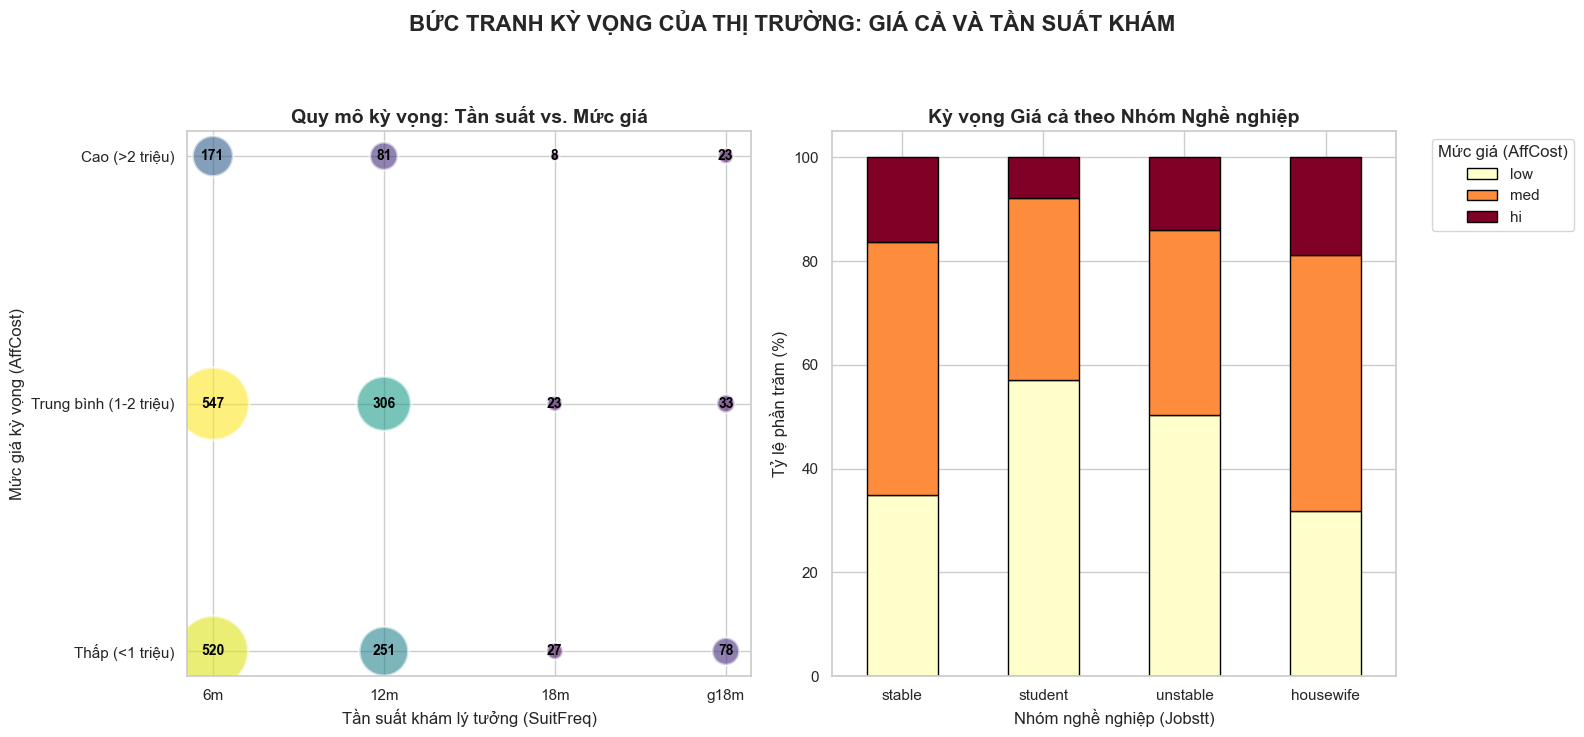

10.1 Ma trận số lượng Tần suất (SuitFreq) và Mức giá (AffCost):
SuitFreq   6m  12m  18m  g18m
AffCost                      
low       520  251   27    78
med       547  306   23    33
hi        171   81    8    23

10.2 Tỷ lệ % Mức giá kỳ vọng theo Nghề nghiệp (Jobstt):
AffCost      low    med     hi
Jobstt                        
stable     35.00  48.71  16.30
student    57.12  35.04   7.85
unstable   50.29  35.67  14.04
housewife  31.76  49.41  18.82


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "BỨC TRANH KỲ VỌNG CỦA THỊ TRƯỜNG: GIÁ CẢ VÀ TẦN SUẤT KHÁM",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)

# Định nghĩa thứ tự hiển thị cho logic
freq_order = ["6m", "12m", "18m", "g18m"]
cost_order = ["low", "med", "hi"]
job_order = ["stable", "student", "unstable", "housewife"]  # Chỉ lấy 4 nhóm chính

# Biểu đồ 1: Bubble Chart (Bong bóng) cho AffCost vs SuitFreq
# Tạo bảng đếm số lượng cho từng tổ hợp
bubble_data = df.groupby(["AffCost", "SuitFreq"]).size().reset_index(name="Count")

# Chuyển đổi text thành số (tọa độ x, y) để vẽ Scatter/Bubble
cost_map = {k: v for v, k in enumerate(cost_order)}
freq_map = {k: v for v, k in enumerate(freq_order)}

# Lọc bỏ những giá trị không nằm trong order (nếu có null hoặc rác)
bubble_data = bubble_data[
    bubble_data["AffCost"].isin(cost_order) & bubble_data["SuitFreq"].isin(freq_order)
]
bubble_data["x"] = bubble_data["SuitFreq"].map(freq_map)
bubble_data["y"] = bubble_data["AffCost"].map(cost_map)

# Vẽ Scatter với kích thước (s) dựa trên số lượng (Count)
scatter = axes[0].scatter(
    x=bubble_data["x"],
    y=bubble_data["y"],
    s=bubble_data["Count"] * 5,
    alpha=0.6,
    c=bubble_data["Count"],
    cmap="viridis",
    edgecolors="w",
    linewidth=2,
)
axes[0].set_xticks(range(len(freq_order)))
axes[0].set_xticklabels(freq_order)
axes[0].set_yticks(range(len(cost_order)))
axes[0].set_yticklabels(["Thấp (<1 triệu)", "Trung bình (1-2 triệu)", "Cao (>2 triệu)"])
axes[0].set_title(
    "Quy mô kỳ vọng: Tần suất vs. Mức giá", fontsize=14, fontweight="bold"
)
axes[0].set_xlabel("Tần suất khám lý tưởng (SuitFreq)")
axes[0].set_ylabel("Mức giá kỳ vọng (AffCost)")

# Thêm text số lượng vào giữa các bong bóng
for i in range(len(bubble_data)):
    axes[0].text(
        bubble_data["x"].iloc[i],
        bubble_data["y"].iloc[i],
        str(bubble_data["Count"].iloc[i]),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

# Biểu đồ 2: 100% Stacked Bar Chart cho AffCost theo Jobstt
# Lọc ra các nhóm nghề nghiệp chính
df_job = df[df["Jobstt"].isin(job_order)]
cross_cost_job = pd.crosstab(df_job["Jobstt"], df_job["AffCost"], normalize="index")

# Reindex để đảm bảo đúng thứ tự
if set(cost_order).issubset(cross_cost_job.columns):
    cross_cost_job = cross_cost_job[cost_order] * 100
else:
    cross_cost_job = cross_cost_job * 100

cross_cost_job = cross_cost_job.reindex(job_order)

cross_cost_job.plot(
    kind="bar", stacked=True, ax=axes[1], colormap="YlOrRd", edgecolor="black"
)
axes[1].set_title(
    "Kỳ vọng Giá cả theo Nhóm Nghề nghiệp", fontsize=14, fontweight="bold"
)
axes[1].set_xlabel("Nhóm nghề nghiệp (Jobstt)")
axes[1].set_ylabel("Tỷ lệ phần trăm (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Mức giá (AffCost)", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ĐỂ NHẬN XÉT ---
print("10.1 Ma trận số lượng Tần suất (SuitFreq) và Mức giá (AffCost):")
cross_freq_cost = pd.crosstab(df["AffCost"], df["SuitFreq"])
if set(freq_order).issubset(cross_freq_cost.columns) and set(cost_order).issubset(
    cross_freq_cost.index
):
    cross_freq_cost = cross_freq_cost.reindex(index=cost_order, columns=freq_order)
print(cross_freq_cost)

print("\n10.2 Tỷ lệ % Mức giá kỳ vọng theo Nghề nghiệp (Jobstt):")
print(cross_cost_job.round(2))


#### Nhận xét:
Bảng ma trận chéo giữa Mức giá (AffCost) và Tần suất (SuitFreq) đã vẽ ra vùng nhu cầu lớn nhất của thị trường y tế dự phòng:

- Tần suất lý tưởng là 6 - 12 tháng: Tuyệt đại đa số người dùng đều ý thức được việc cần đi khám 1 đến 2 lần/năm. Các cột 6m và 12m chiếm áp đảo về số lượng ở mọi mức giá. Số người chọn khám thưa thớt (18m hoặc >18m) là rất thấp.

- Mỏ vàng "Tầm trung" (Medium) và "Giá rẻ" (Low): Sự hội tụ nhu cầu lớn nhất nằm ở 2 cụm: Gói khám 6 tháng mức giá Trung bình (547 người) / Mức giá Thấp (520 người); và Gói khám 12 tháng mức giá Trung bình (306 người) / Mức giá Thấp (251 người). Ngược lại, mức giá Cao (hi > 2 triệu) nhận sự ghẻ lạnh từ thị trường (chỉ có 171 người chọn cho mốc 6 tháng).

- Insight cốt lõi: Khách hàng có nhu cầu khám rất thường xuyên, nhưng "túi tiền" của họ chỉ chịu đựng được mức chi trả dưới 2 triệu đồng/lần. Việc các phòng khám tư nhân hiện nay cố nhồi nhét quá nhiều xét nghiệm không cần thiết để đẩy giá lên 3-5 triệu đồng chính là lý do khiến bệnh nhân "một đi không trở lại".

***Chiến lược Định giá phân mảnh theo Nghề nghiệp (Price Segmentation)***  
Dữ liệu phân tích mức giá theo nhóm nghề nghiệp đã khớp nối hoàn hảo với rào cản tài chính (Wstmon) ở Phần 4, chứng minh rằng không thể áp dụng một mức giá chung cho mọi tệp khách hàng:

- Tệp khách hàng nhạy cảm về giá (Sinh viên & Lao động tự do): Có đến 57.12% sinh viên và 50.29% lao động tự do chỉ chấp nhận mức giá low (dưới 1 triệu đồng). Họ chưa tự chủ tài chính hoặc thu nhập bấp bênh, nên rào cản về giá là tuyệt đối. Nếu phòng khám chỉ có các gói khám tiêu chuẩn từ 2 triệu trở lên, họ chắc chắn sẽ mất trắng tập khách hàng này.

- Tệp khách hàng ưu tiên chất lượng (Người đi làm & Nội trợ): Nhóm có công việc ổn định (stable) và nội trợ (housewife) thể hiện sức mua tốt hơn hẳn. Mức giá họ sẵn sàng chi trả nhiều nhất là mốc med (1-2 triệu đồng), chiếm xấp xỉ 49%. Nhóm nội trợ thậm chí có tỷ lệ chấp nhận giá hi (cao) lớn nhất toàn tập (18.82%), vì họ thường là "tay hòm chìa khóa", trực tiếp nắm ngân sách và rất quan tâm đến sức khỏe gia đình.

***Bức tranh kỳ vọng này phản ánh đúng "Lỗ hổng của thị trường Y tế tư nhân Việt Nam".***

- Hiện nay, người dân đang bị kẹt giữa 2 thái cực: (1) Khám BHYT tuyến công lập thì rẻ (gần như miễn phí) nhưng quá tải, chờ đợi mệt mỏi (Wsttime / Respon kém); (2) Khám dịch vụ tại các bệnh viện tư nhân lớn (như Vinmec, Tâm Anh, Thu Cúc) thì rất nhanh, thái độ tốt nhưng các gói khám tổng quát cơ bản thường dao động từ 2.500.000đ đến 4.000.000đ (vượt xa mức med 1-2 triệu mà số đông dữ liệu đang kỳ vọng).

- Vì sự thiếu hụt các sản phẩm y tế "chất lượng tư nhân nhưng giá tầm trung", phần lớn người lao động phổ thông và sinh viên đành chọn giải pháp "không đi khám nữa" hoặc tự tra Google bắt bệnh như đã phân tích ở Phần 9.

***Đề xuất Giải pháp Kinh doanh***:  
**Dữ liệu đã cung cấp đủ luận cứ để nhóm nghiên cứu đề xuất (Funnel Product Strategy) cho các cơ sở y tế:**  

**1. Gói "Sinh viên" (Giá Low - Dưới 1 triệu): Gói tinh gọn (chỉ khám lâm sàng, siêu âm cơ bản và xét nghiệm máu thường quy), bán lấy số lượng và tiếp cận nhóm Gen Z để hình thành thói quen.**  

**2. Gói "Dân văn phòng" (Giá Med - Từ 1 đến 2 triệu): Gói tiêu chuẩn, bổ sung thêm tầm soát viêm gan, dạ dày (phù hợp với lối sống văn phòng). Đây sẽ là dòng sản phẩm mang lại doanh thu chủ lực. Có thể kết hợp trả góp qua thẻ tín dụng.**  

**3. Gói "An tâm Gia đình" (Dành cho Nội trợ - Mức giá linh hoạt Med đến Hi): Bán theo combo, thiết kế không gian khám riêng tư, chăm sóc tận tình vì nhóm nội trợ sẵn sàng chi trả cao nếu dịch vụ đủ tốt (Empathy và Assurance).**

# PHẦN 11: YẾU TỐ CÔNG NGHỆ BÙ ĐẮP KHOẢNG TRỐNG (GIẢI PHÁP - CLO3 & CLO4)

***Mục tiêu***   
***Biểu đồ 1: Xem xét nhóm "Bác sĩ Google" (những người thích selfstudy ở Phần 9) có sẵn sàng dùng App Y tế (UseIT) không? (Nếu có, đây chính là tệp khách hàng lõi của chúng ta).***  
***Biểu đồ 2: Đánh giá sức mạnh chuyển đổi của App (AfterIT). Liệu một cái thông báo trên điện thoại có đủ sức kéo những người lười đi khám (g24 hoặc unknow) đến phòng khám hay không?***

<Figure size 800x600 with 0 Axes>

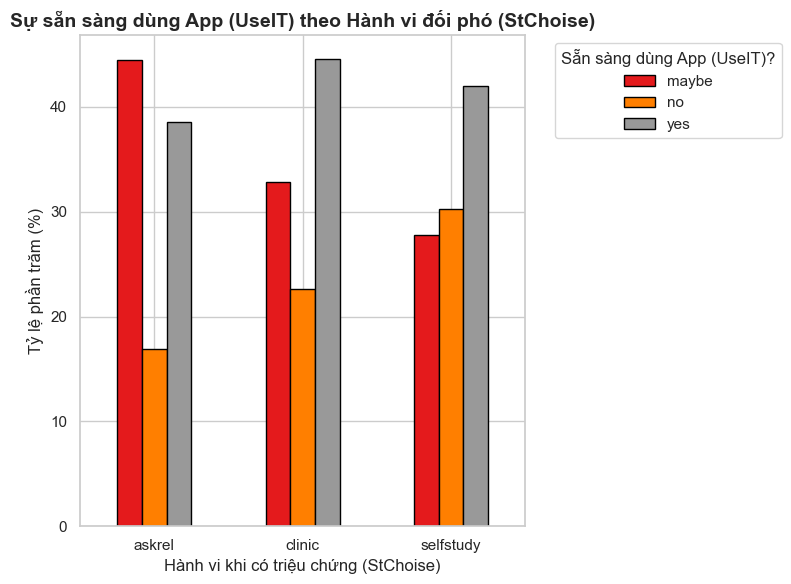

11.1 Tỷ lệ % Sẵn sàng dùng App (UseIT) theo Thói quen (StChoise):
UseIT      maybe     no    yes
StChoise                      
askrel     44.50  16.91  38.59
clinic     32.81  22.58  44.61
selfstudy  27.77  30.23  42.00

Số lượng thực tế chung (UseIT):
UseIT
yes      871
maybe    721
no       476
Name: count, dtype: int64
------------------------------------------------------------


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- CELL 18.1: MỐI LIÊN HỆ GIỮA HÀNH VI TỰ BẮT BỆNH VÀ SỰ SẴN SÀNG DÙNG APP (UseIT) ---
plt.figure(figsize=(8, 6))
cross_useit_stchoise = pd.crosstab(df["StChoise"], df["UseIT"], normalize="index") * 100

cross_useit_stchoise.plot(
    kind="bar", figsize=(8, 6), colormap="Set1", edgecolor="black"
)
plt.title(
    "Sự sẵn sàng dùng App (UseIT) theo Hành vi đối phó (StChoise)",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Tỷ lệ phần trăm (%)")
plt.xlabel("Hành vi khi có triệu chứng (StChoise)")
plt.xticks(rotation=0)
plt.legend(
    title="Sẵn sàng dùng App (UseIT)?", bbox_to_anchor=(1.05, 1), loc="upper left"
)
plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ĐỂ NHẬN XÉT ---
print("11.1 Tỷ lệ % Sẵn sàng dùng App (UseIT) theo Thói quen (StChoise):")
print(cross_useit_stchoise.round(2))
print("\nSố lượng thực tế chung (UseIT):")
print(df["UseIT"].value_counts())
print("-" * 60)


#### Nhận xét:
**Phân tích Sự sẵn sàng đón nhận Y tế số (HealthTech Adoption)**  
Kết quả khảo sát về mức độ sẵn sàng sử dụng Ứng dụng Y tế (App) phân theo thói quen đối phó bệnh tật (StChoise) đã phác họa rõ nét tiềm năng số hóa của thị trường y tế:

- Sự cởi mở với Công nghệ y tế (Tổng quan): Dữ liệu chung cho thấy tín hiệu cực kỳ lạc quan. Có tới 871 người (42.1%) chắc chắn "Có" (yes) và 721 người (34.9%) "Có thể" (maybe) sẽ sử dụng App y tế. Nghĩa là có đến 77% thị trường tiềm năng sẵn sàng mở lòng với giải pháp công nghệ. Nhóm từ chối hoàn toàn (no) chỉ chiếm thiểu số (476 người). Điều này khẳng định việc xây dựng một nền tảng Mobile App tích hợp AI là hoàn toàn khả thi và hợp thời.

- Nhóm "Bệnh nhân chuẩn mực" (Clinic): Những người có thói quen đến thẳng phòng khám khi ốm lại chính là nhóm sẵn sàng dùng App nhất (Tỷ lệ yes cao nhất: 44.61%).

	- Insight: Nhóm này đã có sẵn ý thức y tế, họ nhìn nhận App như một công cụ "tối ưu hóa trải nghiệm" (đặt lịch nhanh, xem kết quả xét nghiệm online, tránh rào cản chờ đợi Wsttime ở Phần 4). Đây chính là tệp khách hàng lõi (Core Users) mà App cần nhắm tới trong giai đoạn đầu ra mắt.

- Nhóm "Bác sĩ Google" (Self-study) - Nghịch lý của thế hệ số: Điểm thú vị nhất của dữ liệu nằm ở nhóm thích tự tra cứu. Mặc dù họ là những người rất thạo công nghệ (tỷ lệ yes khá cao: 42.0%), nhưng họ lại có tỷ lệ chối từ App (no) cao nhất toàn tập: 30.23%.

	- Giải thích nguyên nhân: Tại sao người thích dùng smartphone tra bệnh lại từ chối dùng App y tế? Lý do là họ cho rằng Google đã là đủ (vừa miễn phí, vừa nhanh). Họ e ngại các App của phòng khám sinh ra chỉ để "chèo kéo" mua gói khám.

	- Đề xuất giải pháp: Để thuyết phục được 30% những người từ chối này, App y tế không thể chỉ là một "tờ rơi điện tử" hay "kênh đặt lịch". Nó bắt buộc phải có hàm lượng công nghệ cao (Machine Learning): ví dụ như tính năng phân tích triệu chứng tự động (AI Symptom Checker), hay dự đoán nguy cơ sức khỏe cá nhân hóa. Chỉ khi cung cấp được giá trị vượt trội hơn Google, App mới thu phục được nhóm Gen Z này.

- Nhóm "Phụ thuộc gia đình" (Askrel): Nhóm này chủ yếu nằm ở vùng "lưỡng lự" (Tỷ lệ maybe cao kỷ lục: 44.50%). Họ thiếu chính kiến và hành động dựa trên lời khuyên của người khác.

	- Đề xuất giải pháp: Đối với nhóm này, App cần phát triển tính năng "Tài khoản gia đình" (Family Account). Chỉ cần thuyết phục được 1 người trong nhà cài App, người đó sẽ dễ dàng thêm hồ sơ sức khỏe và đặt lịch khám cho các thành viên khác trong gia đình (Tận dụng sức mạnh của biến Habit ở Phần 7).

<Figure size 800x600 with 0 Axes>

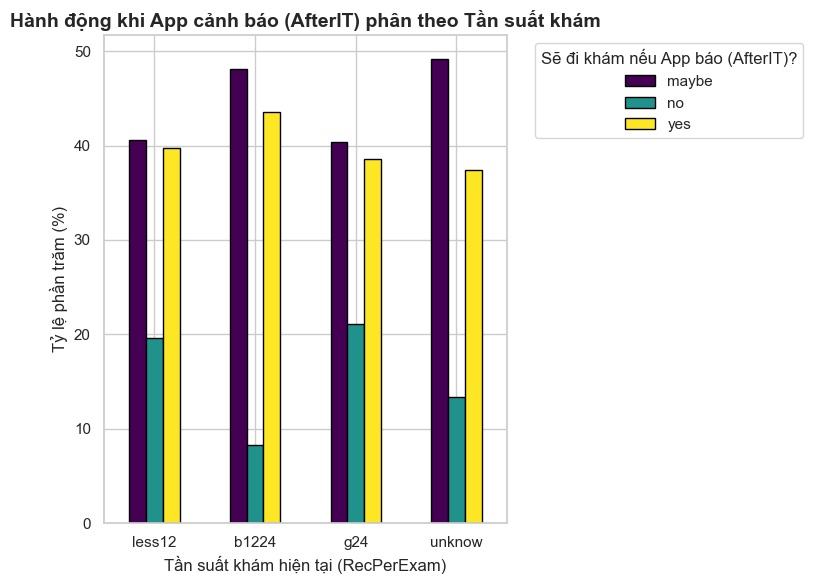

11.2 Tỷ lệ % Hành động sau khi App cảnh báo (AfterIT) theo Tần suất khám (RecPerExam):
AfterIT     maybe     no    yes
RecPerExam                     
less12      40.60  19.64  39.75
b1224       48.17   8.26  43.58
g24         40.36  21.09  38.55
unknow      49.22  13.37  37.40

Số lượng thực tế chung (AfterIT):
AfterIT
maybe    900
yes      815
no       353
Name: count, dtype: int64


In [36]:
# --- CELL 18.2: SỨC MẠNH CHUYỂN ĐỔI CỦA APP (AfterIT) ĐỐI VỚI NHÓM LƯỜI KHÁM ---
plt.figure(figsize=(8, 6))
rec_order = ["less12", "b1224", "g24", "unknow"]
cross_afterit_rec = pd.crosstab(df["RecPerExam"], df["AfterIT"], normalize="index")

# Đảm bảo đúng thứ tự thời gian
if set(rec_order).issubset(cross_afterit_rec.index):
    cross_afterit_rec = cross_afterit_rec.reindex(rec_order)
cross_afterit_rec = cross_afterit_rec * 100

cross_afterit_rec.plot(
    kind="bar", figsize=(8, 6), colormap="viridis", edgecolor="black"
)
plt.title(
    "Hành động khi App cảnh báo (AfterIT) phân theo Tần suất khám",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Tỷ lệ phần trăm (%)")
plt.xlabel("Tần suất khám hiện tại (RecPerExam)")
plt.xticks(rotation=0)
plt.legend(
    title="Sẽ đi khám nếu App báo (AfterIT)?",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

# --- IN RA THÔNG SỐ KẾT QUẢ ĐỂ NHẬN XÉT ---
print(
    "11.2 Tỷ lệ % Hành động sau khi App cảnh báo (AfterIT) theo Tần suất khám (RecPerExam):"
)
print(cross_afterit_rec.round(2))
print("\nSố lượng thực tế chung (AfterIT):")
print(df["AfterIT"].value_counts())


#### Nhận xét:  
**Sức mạnh chuyển đổi của Công nghệ: Từ "Trì hoãn" đến "Hành động"**  
Biểu đồ phân tích hành vi sau khi nhận cảnh báo từ Ứng dụng Y tế (AfterIT) đối chiếu với tần suất khám hiện tại (RecPerExam) đã mang lại một kết luận cực kỳ giá trị về mặt hành vi học:

- Sức mạnh của "Cú hích" (Nudge Theory): Nhìn vào tổng thể, chỉ có khoảng 17% (353 người) kiên quyết từ chối (no) đi khám dù có app nhắc nhở. Hơn 83% còn lại rơi vào trạng thái "Chắc chắn đi" (yes - 815 người) hoặc "Có thể suy nghĩ lại" (maybe - 900 người). Điều này chứng minh lý thuyết "Cú hích" trong Kinh tế học Hành vi: Đôi khi người ta lười đi khám không phải vì họ không sợ chết, mà vì họ thiếu một "cái cớ", một sự nhắc nhở đủ sức nặng tại đúng thời điểm.

- Khai phá tệp khách hàng "Ngủ đông" (Nhóm g24 và unknow): Đây là những người đã bỏ bê sức khỏe trên 2 năm hoặc không nhớ lần cuối đi khám. Dữ liệu cho thấy, nếu có một App y tế phân tích và gửi cảnh báo rủi ro, có tới 38.55% (nhóm g24) và 37.4% (nhóm unknow) sẽ lập tức chuyển đổi trạng thái thành "Đồng ý đi khám" (yes). Tỷ lệ lưỡng lự (maybe) ở hai nhóm này cũng rất cao (trên 40%). Đây là một tỷ lệ chuyển đổi (Conversion Rate) khổng lồ mà các kênh Marketing truyền thống (như phát tờ rơi, gọi điện telesale) không bao giờ đạt được.

- Chạm đúng "Điểm ngứa" của nhóm Trì hoãn (b1224): Nhóm 1-2 năm chưa đi khám là nhóm có tỷ lệ đồng ý (yes: 43.58%) và lưỡng lự (maybe: 48.17%) cao nhất. Tỷ lệ từ chối của họ chỉ vỏn vẹn 8.26%. Rõ ràng, họ đã có ý thức rục rịch muốn đi khám, chỉ chờ một thông báo "Đã đến hạn tầm soát" từ điện thoại để kích hoạt hành vi.

## TỔNG KẾT CHƯƠNG PHÂN TÍCH KHÁM PHÁ (EDA) & BƯỚC ĐỆM CHO MACHINE LEARNING

Trải qua 11 phần bóc tách dữ liệu từ hơn 2,000 mẫu khảo sát, chúng ta đã vẽ ra được một bức tranh toàn cảnh (Big Picture) cực kỳ sắc nét về thị trường Y tế dự phòng:

- Nỗi đau (Pain points): Người dân bị cản bước bởi một ma trận rào cản. Đó là quỹ thời gian eo hẹp, chi phí y tế đắt đỏ, sự kém cỏi trong cách truyền đạt của y bác sĩ và cả những nỗi sợ tâm lý vô hình.

- Kỳ vọng (Expectations): Họ mong muốn những gói khám giá cả phải chăng (từ 1-2 triệu đồng), được thiết kế riêng theo đặc thù nghề nghiệp và độ tuổi.

- Giải pháp (The Solution): Họ sẵn sàng đón nhận công nghệ. Một ứng dụng di động (Mobile App) được chứng minh là có khả năng phá vỡ sự trì hoãn và kéo họ quay lại phòng khám.

*$\Rightarrow$ Bước đệm cho Machine Learning: Từ những hiểu biết sâu sắc này, chúng ta đã xác định được các đặc trưng (Features) quan trọng nhất để đưa vào huấn luyện mô hình AI. Những biến như FlwHealth (theo dõi tin tức sức khỏe), Habit (thói quen gia đình), StChoise (cách đối phó khi có triệu chứng) sẽ là những "Super Features" có sức mạnh dự báo cực cao về việc một người có đi khám định kỳ hay không. Mô hình AI sẽ học được các quy luật hành vi phức tạp từ dữ liệu này để đưa ra dự đoán chính xác và đề xuất cá nhân hóa trong giai đoạn triển khai thực tế.*